In [ ]:
# # terminal de instalação
# !pip install numpy
# !pip install python-magic-bin
# !pip uninstall matplotlib seaborn -y
# !pip install matplotlib seaborn
# !pip install --upgrade pip
# !pip install ninja
# !pip install matplotlib --force-reinstall --no-binary :all:
# !pip install seaborn
# !pip install meson
# !pip uninstall matplotlib seaborn -y
# !pip install matplotlib seaborn
# !pip install pandas
# !pip install ibge
# !pip install sidrapy
# !pip install scikit-learn
# !pip install neuralforecast
# !pip freeze > requirements.txt
# !pyenv install 3.11.6
# !pyenv global 3.11.6
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
# !pip install xgboost




# Requeiments

In [27]:
import os
import sys
import pandas as pd
import seaborn as sn
import numpy as np
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import requests
import sidrapy
from ibge.localidades import *
import torch
from datetime import datetime

# Importando os dados da base WSUS

### Documentação das variáveis


### Variaveis identificadas na documentação

- TP_NOT: Tipo de Notificação [varchar(1)] # Valor Constante

        1 – Negativa

        2 – Individual

        3 – Surto

        4 – Agregado 

- TP_NOT.1: Tipo de Notificação  - 2 - Individual [varchar(1)] # Valor Constante

- ID_AGRAVO: Identificação de Agravo/Doença (CID) [varchar2(4)] # Valor Constante

- DT_NOTIFIC: Data da Notificação [date] # Ano mais importante

- NU_ANO: Ano da Notificação [varchar(4)]

- SG_UF_NOT: SG ? UF do Estado de Notificação [varchar(2)]

- ID_MUNICIP: Id de identificação do Municipio [varchar(6)]

- ID_REGIONA: Código da regional de saúde da tabela de município do sistema [varchar2(4)]

- ID_UNIDADE: Códigos e nomes de estabelecimento [varchar(7)] # sem necessidade

- DT_DIAG: Data do inicio do tratamento [date]

- SEM_DIAG: Semana epidemiológica do diagnóstico do caso notificado [varchar(6)]

- ANO_NASC: Ano de Nascimento [date]

- NU_IDADE_N: Idade, com Código (4 - Ano e 0 para completar) A composição da variável obedece o seguinte critério: 1° dígito: Ex: 3009 – nove meses, 4018 – dezoito anos  [number(4)]

        1. Hora

        2. Dia

        3. Mês

        4. Ano
        
- CS_SEXO: Sexo [varchar(1)]

        0. Masculino

        1. Feminino

- CS_GESTANT: Código Gestante [varchar2(1)] # Não usar
        1. 1ºTrimestre 

        2. 2ºTrimestre 

        3. 3ºTrimestre

        4. Idade gestacional Ignorada 

        5. Não 

        6. Não se aplica

        9. Ignorado
        
- CS_RACA: Código Raça [varchar2(1)]

        1. Branca 

        2. Preta 

        3. Amarela

        4. Parda 

        5. Indígena 

        9. Ignorado

- CS_ESCOL_N: Código Escolaridade [varchar2(2)]

        0. Analfabeto 

        1. 1ª a 4ª série incompleta do EF (antigo primário ou 1º grau) 

        2. 4ª série completa do EF (antigo primário ou 1º grau)

        3. 5ª à 8ª série incompleta do EF (antigo ginásio ou 1º grau) 

        4. Ensino fundamental completo (antigo ginásio ou 1º grau) 

        5. Ensino médio incompleto (antigo colegial ou 2º grau )

        6. Ensino médio completo (antigo colegial ou 2º grau ) 

        7. Educação superior incompleta 

        8. Educação superior completa 

        9. Ignorado 

        10. Não se aplica

- SG_UF: Código do Estado Notificante  [varchar(2)]

- ID_MN_RESI: Código do município de residência do caso notificado  [varchar2(6)]

- ID_RG_RESI: Regional de saúde onde está localizado o município de residência do paciente por ocasião da notificação [varchar2(4)]

- ID_PAIS: País onde residia o paciente por ocasião da notificação  [varchar(4)]

- NDUPLIC_N: Identifica duplicidade  [varchar2(1)]

        0 ou branco – Não identificado

        1 – Não é duplicidade (nãolistar)

        2 – Duplicidade (não contar) 

- DT_DIGITA: Data de digitação [date]

- DT_TRANSUS: Data de transferência da unidade de saúde [date]

- DT_TRANSDM: Data de transferência do distrito municipal [date]

- DT_TRANSSM: Data de transferência da secretaria municipal de saúde [date]

- DT_TRANSRM: Data de transferência da regional municipal [date] # Valor Constante

- DT_TRANSRS: Data de transferência da regional de saúde [date]

- DT_TRANSSE: Data de transferência da secretaria estadual de saúde [date]

- NU_LOTE_V: Identifica o Lote da transferência da notificação um nível do sistema para outro

- NU_LOTE_H: Identifica do Lote da transferência de registros dentro de um mesmo nível do sistema

- CS_FLXRET: Identifica se o registro está habilitado ou foi enviado pelo fluxo de retorno para o município de residência # Valor Constante

        0 - Não

        1 - habilitado para envio.

        2 - enviado 

- FLXRECEBI: Identifica se o registro foi recebido pelo fluxo de retorno [varchar2(1)] # Valor Constante

- MIGRADO_W: Identifica se o registro é oriundo da rotina de migração da base Windows. [varchar2(1)]

        1. migrado do Sinan Windows 

- ID_OCUPA_N: Ocupação do indivíduo que sofreu o agravo [varchar2(6)]

- NU_LESOES:  Nº de lesões cutâneas [numeric(2)]

- FORMACLINI: [varchar(1)] 

        1- I -Indeterminada

        2- T - Tuberculóide

        3- D - Dimorfa

        4- V - Virchowiana

        5- Não classificado

- AVALIA_N: Avaliação do Grau de Incapacidade Física no Diagnóstico [varchar(1)]

        0 Grau zero

        1- Grau I

        2- Grau II

        3 - Não avaliado

- CLASSOPERA: Classificação operacional, por ocasião do diagnóstico, para eleição do esquema terapêutico [varchar(1)]

        1- PB - Paucibacilar

        2- MB - Multibacilar

- MODOENTR: Modo de entrada do paciente no sistema [varchar(1)]

        1- Caso novo

        2- Transferencia do mesmo município (outra unidade)

        3- Transferência de outro município (mesma UF)

        4- Transferência de outro estado

        5- Transferencia de outro país

        6- Recidiva

        7- Outros reingressos

        9- Ignorado

- MODODETECT: Modo de detecção do caso novo [varchar(1)]

        1- Encaminhamento

        2- Demanda espontânea

        3- Exame de coletividade

        4- Exame de contatos

        5- Outros modos

        9- Ignorado

- BACILOSCOP: Informar o resultado da baciloscopia [varchar(1)]

        1. Positiva

        2. Negativa

        3. Não realizada

        9. Ignorado

- DTINICTRAT: Data do inicio do tratamento [date]

- ESQ_INI_N: Esquema terapêutico instituído por ocasião do diagnostico [varchar(1)]

        1. PQT/ PB/ 6 doses

        2. PQT/ MB/ 12 doses

        3. Outros Esquemas Substitutos

- CONTREG: Número de pessoas que residam ou tenham residido, nos últimos 5 anos com o doente, a contar da Data do diagnóstico [numeric(2)]

- NERVOSAFET: Número de nervos afetados [numeric(2)]

- UFATUAL : Código da UF do cadastro do IBGE [varchar(2)] # Valor Constante

- ID_MUNI_AT :Código e nome dos municípios do cadastro do IBGE [varchar(6)]

- DT_NOTI_AT: Data de notificação atual [date]

- ID_UNID_AT: Códigos e nomes de estabelecimentos de saúde (CNES) [varchar(7)]

- UFRESAT: Sigla da UF de residência atual do paciente [varchar(2)]

- MUNIRESAT: código IBGE do município de residência atual do paciente [varchar(6)]

- DTULTCOMP: Data do último comparecimento [date]

- CLASSATUAL: Classificação operacional atual [varchar(1)]

        1. PB (Paucibacilar) 

        2. MB (Multibacilar) 

- AVAL_ATU_N: Avaliação de incapacidade física no momento da cura - [varchar(1)]

        0. grau zero

        1. grau I

        2. grau II

        3. Não avaliado

        9- Ignorado

- ESQ_ATU_N: Esquema terapêutico em uso [varchar(1)]

        1- PQT/PB/06 doses

        2- PQT/MB/12 doses

        3- Outros Esquemas Substitutivos

- DOSE_RECEB: Número de doses supervisionadas [numeric(2)]

- EPIS_RACIO: Episódio Reacional Durante o Tratamento [varchar(1)]

        1- Reação tipo 1

        2- Reação tipo 2

        3- Reação tipo 1 e 2

- DTMUDESQ:  Data de mudança do Esquema [date]

- CONTEXAM: Número de contatos examinados [numeric(2)]

- DTALTA_N: Data da alta [date]

- TPALTA_N: Tipo de Saída [varchar(1)]

        1- Cura

        2- transf. p/ mesmo município

        3- transf. p/ outro município

        4- transf. p/ outro Estado

        5- transf. p/ outro país

        6- Óbito

        7- Abandono

        8- Erro diagnóstico

        9- transf. não especificada

- IN_VINCULA: Vinculação [varchar(1)]

        0 - Não Vinculada

        1 - Vinculada
        
- NU_LOTE_IA: Transferência vertical da investigação e do acompanhamento [varchar(7)]

## Ativar o ambiente virtual

In [28]:
# Caminho para o ambiente virtual
venv_path = os.path.join('.', 'venv_health', 'Scripts', 'activate')  # Ajuste para Linux/Mac: 'bin/activate_this.py'

os.system(venv_path)

# Agora o script usará as dependências do ambiente virtual
print("Ambiente virtual ativado:", sys.prefix)

Ambiente virtual ativado: d:\python\data_health\venv_health


# Obter os dados

## Buscando os arquivos já tratados

Os dados são obtidos de um arquivo csv já tratado, caso não tenha o arquivo ele será criado automaticamente pelo script que executará ambas etapas:

- Converter o arquivo .dbc em .csv, gerando o arquivo `HANSENIASE_TOTAL_`

- Pré-processamento dos dados do Wsus¹ gerando o csv já tratado `HANSENIASE_PROCESS_`

In [40]:
print("-----------------------------------BUSCA DOS DADOS JÁ PROCESSADOS---------------------------")
arquivos = []
path_csv = os.path.join('.', 'data', 'HANS')

# Garantir que o diretório existe
if not os.path.exists(path_csv):
    print(f"Diretório não encontrado: {path_csv}")
    os.makedirs(path_csv)  # Criar o diretório se não existir

# Verificar arquivos no diretório
for f in os.listdir(path_csv):
    if f.startswith('HANSENIASE_PROCESS_') and f.endswith('.csv'):
        try:
            # Extrair data do nome do arquivo
            data_str = f.split('_')[-3:]  # Pega os últimos 3 elementos (dd, mm, yyyy)
            data = datetime.strptime('_'.join(data_str).replace('.csv', ''), '%d_%m_%Y')
            arquivos.append((data, f))
        except Exception as e:
            print(f"Arquivo com formato inválido: {f} - {e}")

# Executar script externo se nenhum arquivo for encontrado
if not arquivos:
    print("Nenhum arquivo encontrado. Executando script para gerar arquivo...")
    path_gerar_wsus = os.path.join('.', 'gerar_wsus_csv.py')
    resultado = os.system('python ' + path_gerar_wsus)
    
    if resultado == 0:
        print("Script executado com sucesso. Verificando novo arquivo...")
        # Recarregar lista de arquivos após execução do script
        for f in os.listdir(path_csv):
            if f.startswith('HANSENIASE_PROCESS_') and f.endswith('.csv'):
                try:
                    data_str = f.split('_')[-3:]
                    data = datetime.strptime('_'.join(data_str).replace('.csv', ''), '%d_%m_%Y')
                    arquivos.append((data, f))
                except Exception as e:
                    print(f"Erro ao processar novo arquivo: {f} - {e}")
    else:
        print("Erro na execução do script. Arquivo não gerado.")

# Exibir lista final de arquivos encontrados
print("Arquivos encontrados:", arquivos)

if arquivos:
    # Ordenar arquivos pela data mais recente
    arquivos.sort(reverse=True, key=lambda x: x[0])
    
    # Pegar arquivo mais recente
    ultimo_arquivo = os.path.join(path_csv, arquivos[0][1])
    
    print(f"Carregando arquivo mais recente: {ultimo_arquivo}")
    
    # Carregar dados
    df_dados = pd.read_csv(ultimo_arquivo, encoding='utf-8', low_memory=False)
    
    print("\nPrimeiras linhas do DataFrame:")
    print(f"\nTotal de registros: {len(df_dados):,}")
    print(f"Data de referência: {arquivos[0][0].strftime('%d/%m/%Y')}")
else:
    print("Nenhum arquivo válido encontrado na pasta")

-----------------------------------BUSCA DOS DADOS JÁ PROCESSADOS---------------------------
Arquivos encontrados: [(datetime.datetime(2025, 3, 6, 0, 0), 'HANSENIASE_PROCESS_06_03_2025.csv')]
Carregando arquivo mais recente: .\data\HANS\HANSENIASE_PROCESS_06_03_2025.csv

Primeiras linhas do DataFrame:

Total de registros: 984,035
Data de referência: 06/03/2025


# Analises Graficas

## Ocorrências de casos

### Notificações por Mês

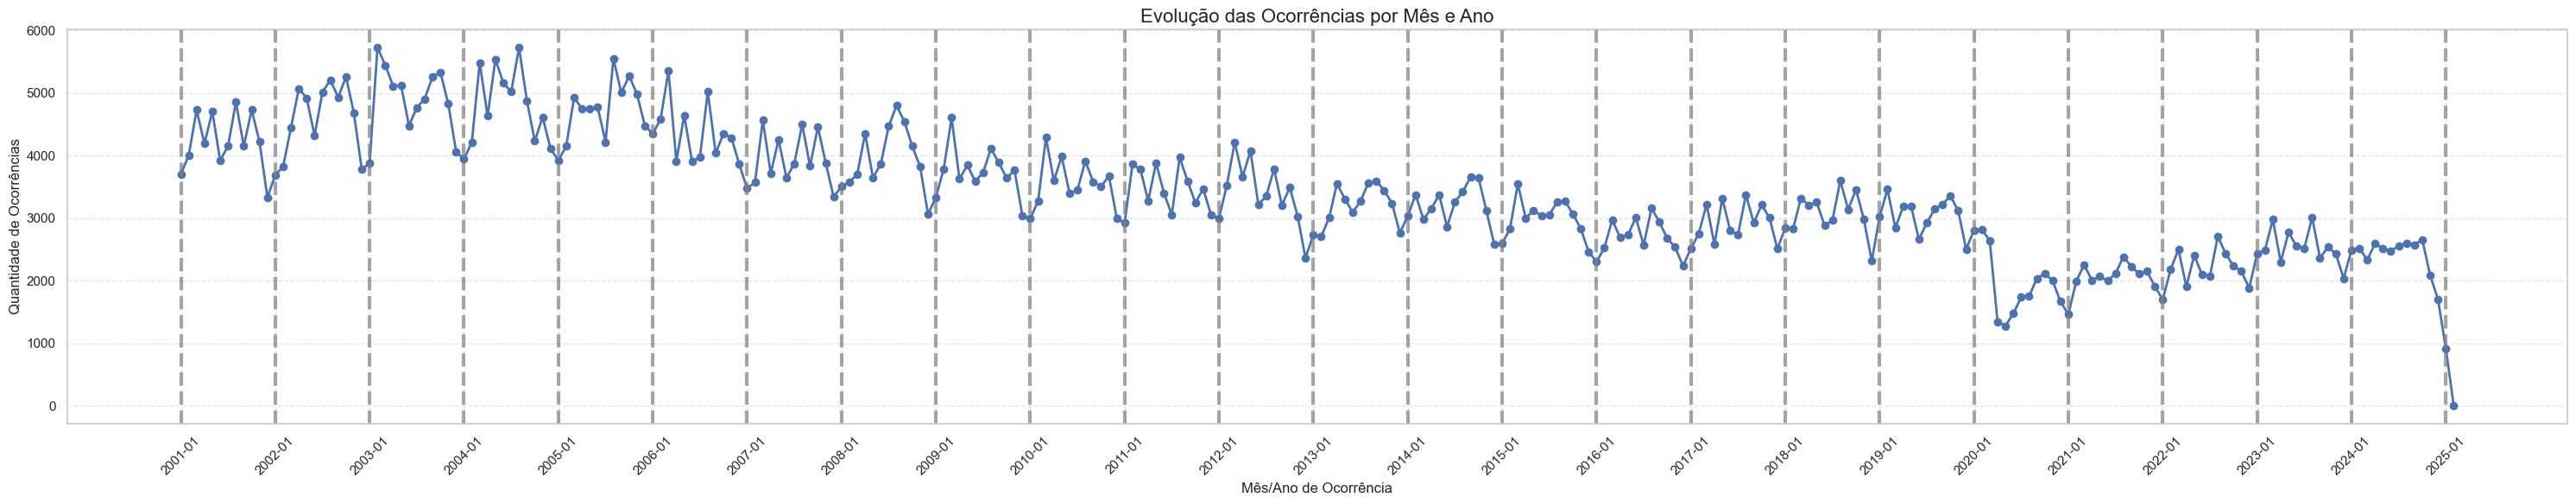

In [41]:
# Converter a coluna DT_NOTIFIC para datetime
df_dados["DT_NOTIFIC"] = pd.to_datetime(df_dados["DT_NOTIFIC"], format='%Y-%m-%d', errors='coerce')

# Criar uma nova coluna no formato "AAAA-MM"
df_dados["ANO_MES"] = df_dados["DT_NOTIFIC"].dt.to_period("M").astype(str)

# Agrupar os dados por "ANO_MES" e contar a quantidade de ocorrências
dados_agrupados = df_dados.groupby("ANO_MES").size().reset_index(name="quantidade")

# Detectar mudanças de ano para adicionar linhas verticais
dados_agrupados["ANO"] = dados_agrupados["ANO_MES"].str[:4]
anos_unicos = dados_agrupados["ANO"].drop_duplicates().index

# Plotar o gráfico de linha com todos os pontos
fig, ax = plt.subplots(figsize=(30, 6))

ax.plot(
    dados_agrupados["ANO_MES"],
    dados_agrupados["quantidade"],
    marker='o',
    linestyle='-',
    linewidth=2,
    color='b'
)

# Configurar título e rótulos dos eixos
ax.set_title("Evolução das Ocorrências por Mês e Ano", fontsize=16)
ax.set_xlabel("Mês/Ano de Ocorrência", fontsize=12)
ax.set_ylabel("Quantidade de Ocorrências", fontsize=12)

# Ajustar os ticks (marcadores) do eixo X para exibir de 6 em 6 meses (somente legenda)
xticks = dados_agrupados["ANO_MES"][::12]  # Seleciona a cada 6 meses
ax.set_xticks(xticks)
ax.set_xticklabels(xticks, rotation=45)

# Adicionar linhas verticais nos inícios de cada ano
for ano_idx in anos_unicos:
    ax.axvline(x=ano_idx, color='gray', linestyle='--', linewidth=3, alpha=0.7)

# Exibir grid para melhor visualização
plt.grid(True, linestyle='--', alpha=0.5)

# Ajustar a disposição do layout
plt.tight_layout()

# Exibir o gráfico
plt.show()


### Notificações por Ano

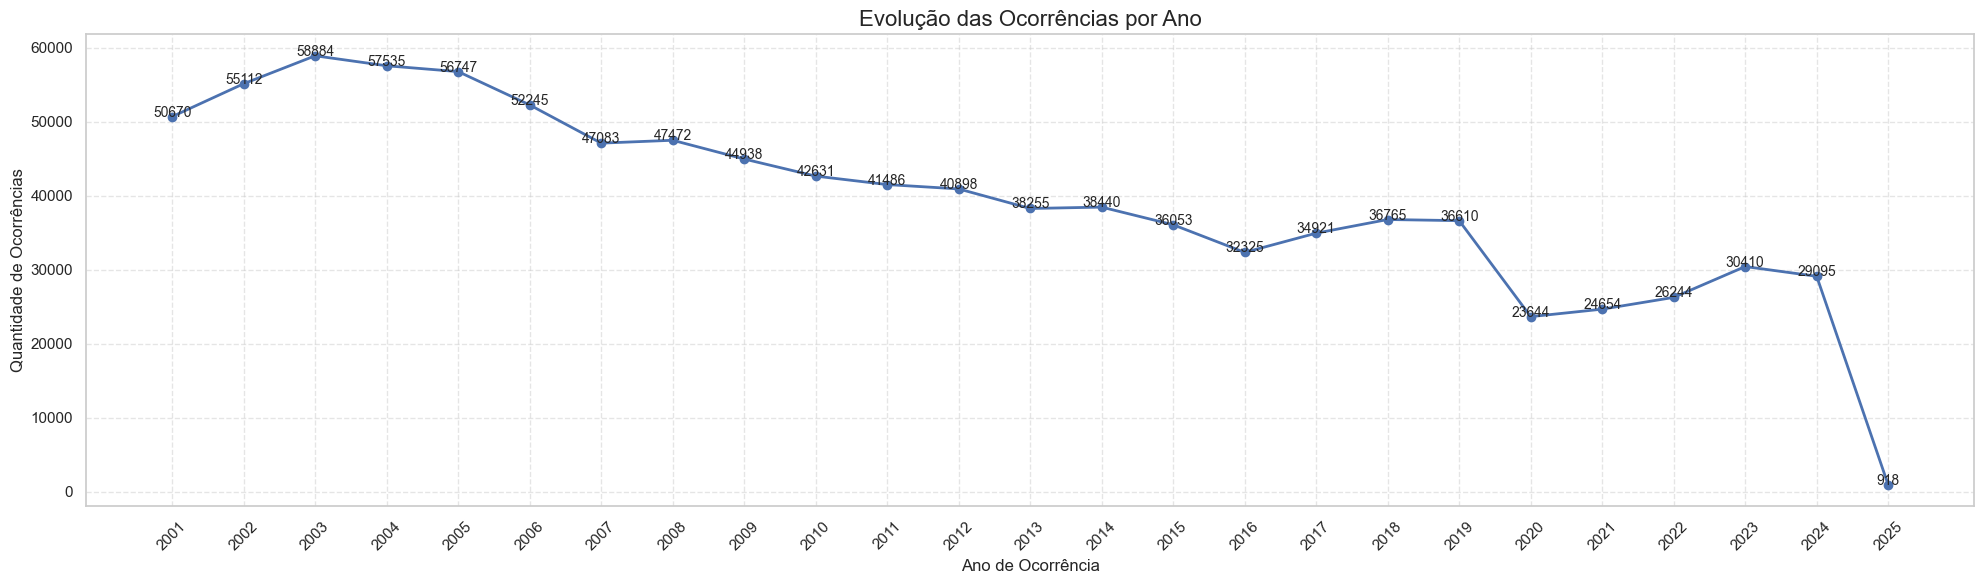

In [42]:
# Agrupar os dados por ano e contar a quantidade de ocorrências
dados_agrupados = df_dados.groupby("NU_ANO").size().reset_index(name="quantidade")

# Plotar o gráfico de linha com os anos no eixo X e a quantidade no eixo Y
fig, ax = plt.subplots(figsize=(20, 6))

ax.plot(
    dados_agrupados["NU_ANO"],
    dados_agrupados["quantidade"],
    marker='o',
    linestyle='-',
    linewidth=2,
    color='b'
)

# Configurar título e rótulos dos eixos
ax.set_title("Evolução das Ocorrências por Ano", fontsize=16)
ax.set_xlabel("Ano de Ocorrência", fontsize=12)
ax.set_ylabel("Quantidade de Ocorrências", fontsize=12)

# Adicionar rótulos nos pontos
for i, txt in enumerate(dados_agrupados["quantidade"]):
    ax.annotate(txt, (dados_agrupados["NU_ANO"][i], dados_agrupados["quantidade"][i]), fontsize=10, ha='center')

# Melhorar a aparência do gráfico
plt.xticks(dados_agrupados["NU_ANO"], rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

# Exibir o gráfico
plt.tight_layout()
plt.show()

### Notificação por Estado

In [43]:
# Busco as informações dos estados
dados_estados = Estados()
if isinstance(dados_estados.json_ibge, (list, dict)):
    dt_est = dados_estados.json_ibge  # Já é uma estrutura Python válida
    print(dt_est)
else:
    dt_est = json.loads(dados_estados.json_ibge)  # Caso seja uma string JSON
    print(dt_est)
dt_est[17]

[{'id': 11, 'sigla': 'RO', 'nome': 'Rondônia', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}, {'id': 12, 'sigla': 'AC', 'nome': 'Acre', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}, {'id': 13, 'sigla': 'AM', 'nome': 'Amazonas', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}, {'id': 14, 'sigla': 'RR', 'nome': 'Roraima', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}, {'id': 15, 'sigla': 'PA', 'nome': 'Pará', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}, {'id': 16, 'sigla': 'AP', 'nome': 'Amapá', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}, {'id': 17, 'sigla': 'TO', 'nome': 'Tocantins', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}, {'id': 21, 'sigla': 'MA', 'nome': 'Maranhão', 'regiao': {'id': 2, 'sigla': 'NE', 'nome': 'Nordeste'}}, {'id': 22, 'sigla': 'PI', 'nome': 'Piauí', 'regiao': {'id': 2, 'sigla': 'NE', 'nome': 'Nordeste'}}, {'id': 23, 'sigla': 'CE', 'nome': 'Ceará', 'regiao': {'id': 2, 'sigla': 'NE', 'nome': 'Nordeste'}}, {'id': 24, 'si

{'id': 32,
 'sigla': 'ES',
 'nome': 'Espírito Santo',
 'regiao': {'id': 3, 'sigla': 'SE', 'nome': 'Sudeste'}}

In [44]:
# Extraindo corretamente as informações de estado e região
dados_est = []
for dado in dt_est:
    linha = {
        "id": dado["id"],
        "sigla": dado["sigla"],
        "nome": dado["nome"],
        "regiao": dado["regiao"]["nome"]  # Acessa o nome da região corretamente
    }
    dados_est.append(linha)

# Criar DataFrame com as informações de estados e regiões
df_estados = pd.DataFrame(dados_est)  
print(df_estados.head())



   id sigla      nome regiao
0  11    RO  Rondônia  Norte
1  12    AC      Acre  Norte
2  13    AM  Amazonas  Norte
3  14    RR   Roraima  Norte
4  15    PA      Pará  Norte


### Casos por Estado (Separado por Região)

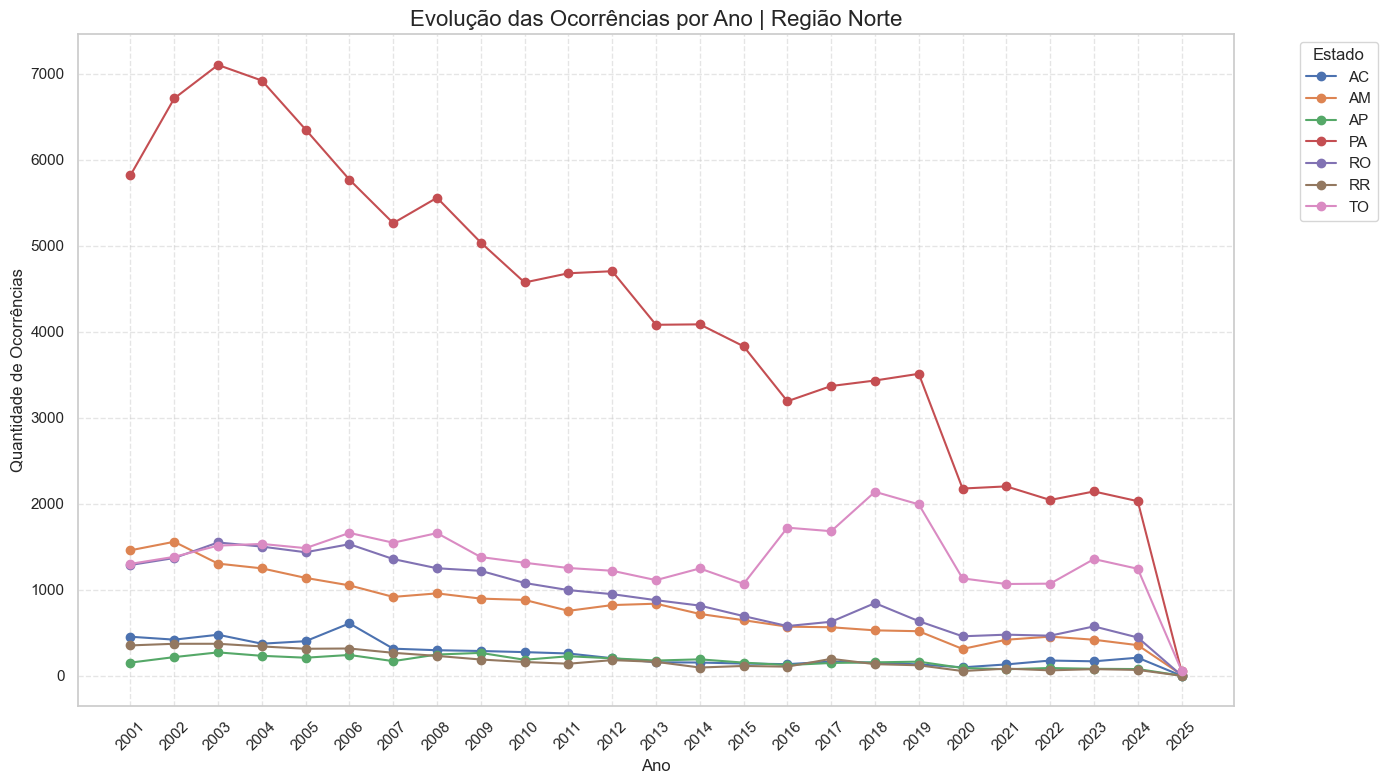

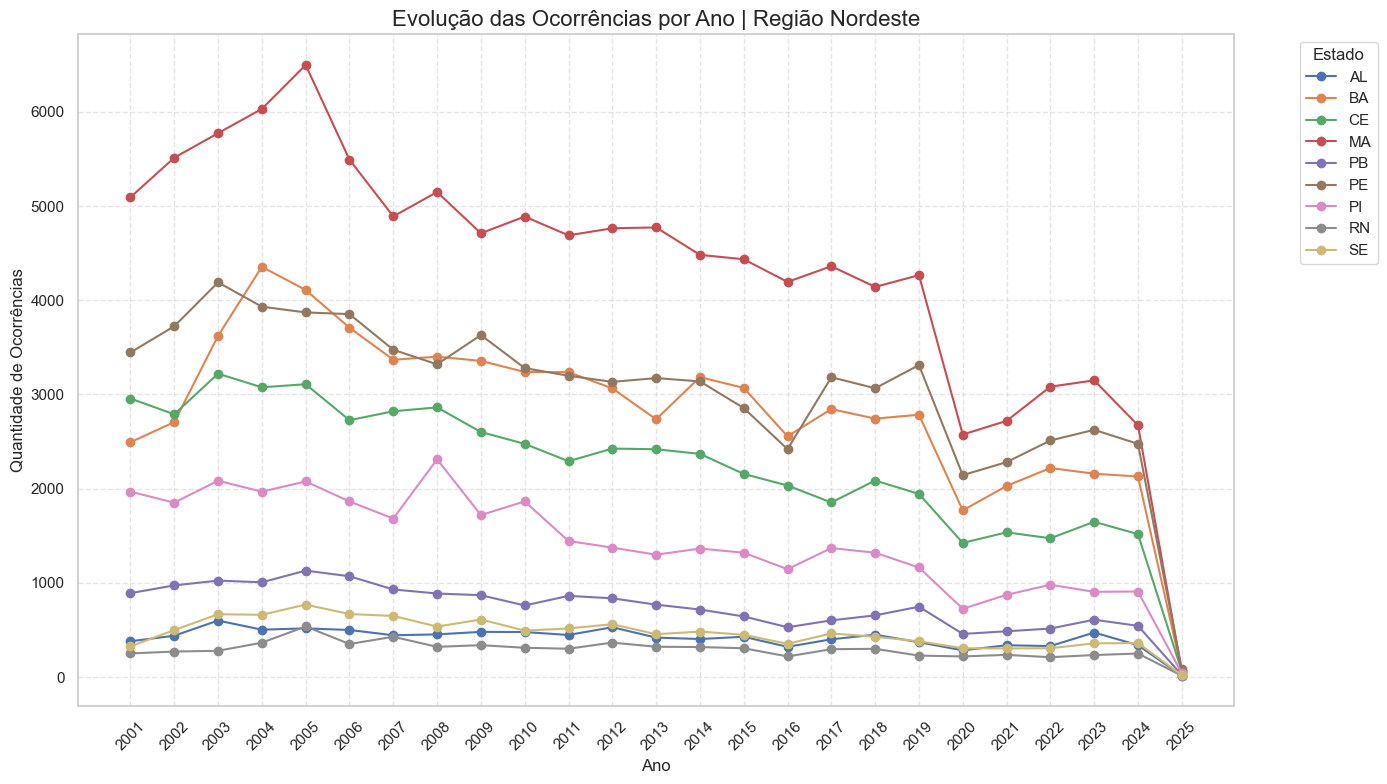

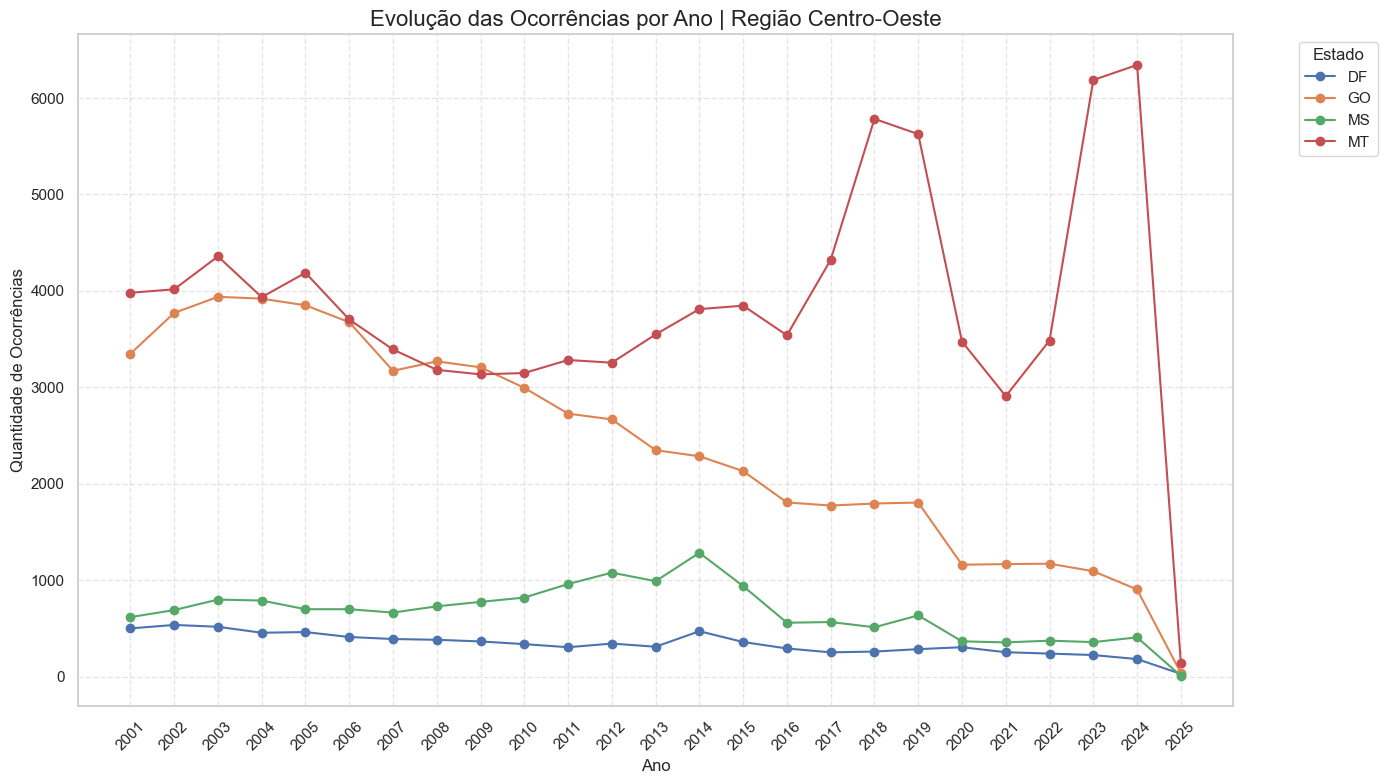

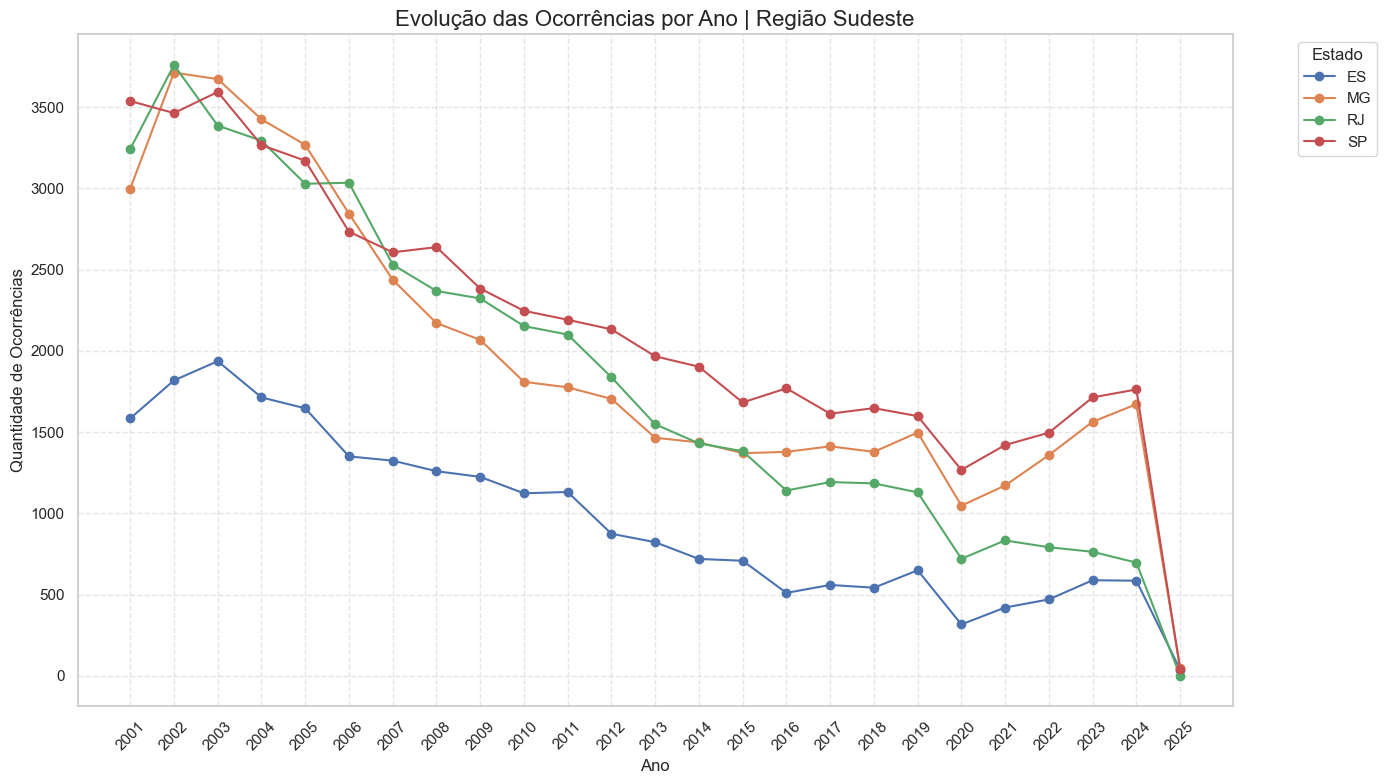

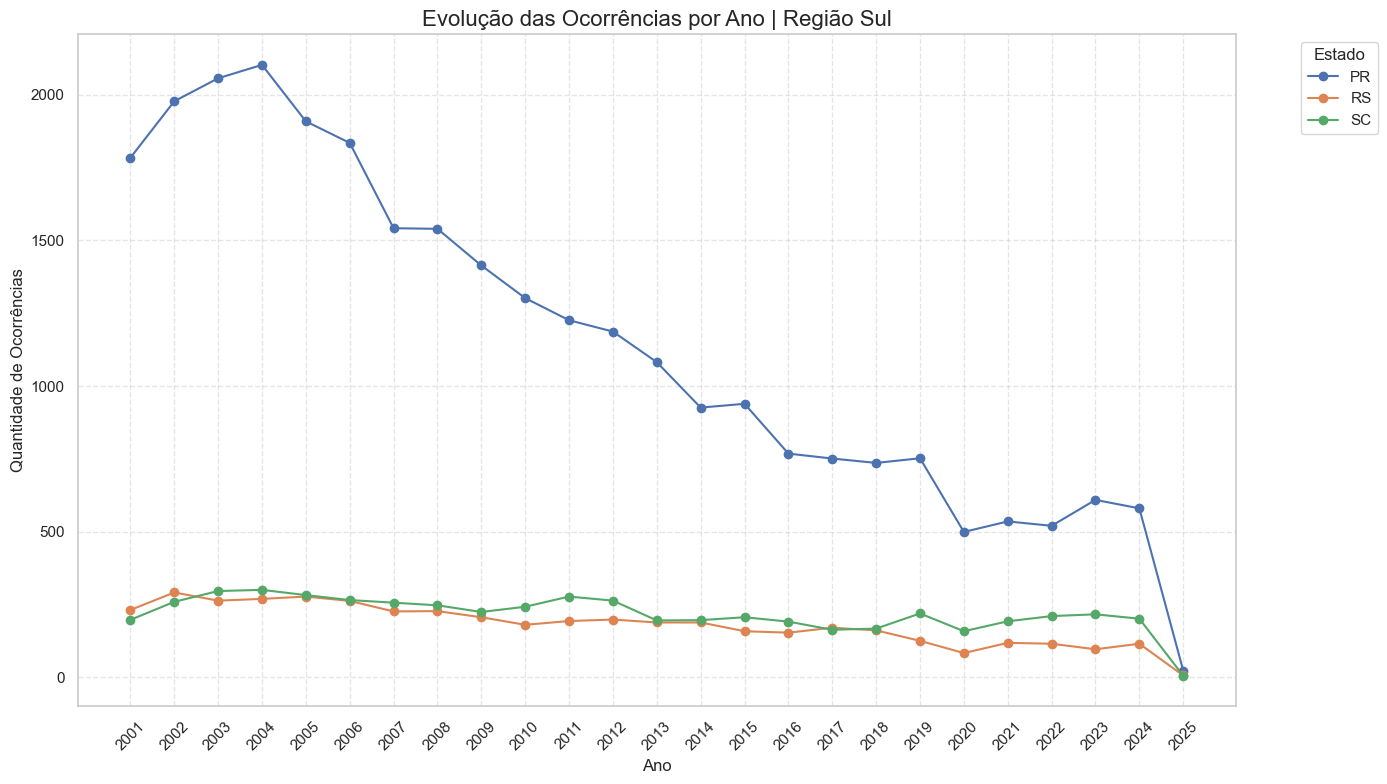

In [45]:
# Criar DataFrame de estados
df_estados = pd.DataFrame(dados_est)

# Adicionar ao DataFrame original uma coluna para os nomes dos estados e regiões
df_dados_estado = df_dados.merge(df_estados[['id', 'sigla', 'regiao']], left_on='SG_UF_NOT', right_on='id', how='left')

# Agrupar por ano, estado e região
dados_agrupados = df_dados_estado.groupby(['NU_ANO', 'sigla', 'regiao']).size().reset_index(name='quantidade')

# Obter lista única de regiões
regioes = dados_agrupados['regiao'].unique()

# Criar gráficos de linha para cada região
for regiao in regioes:
    fig, ax = plt.subplots(figsize=(14, 8))

    dados_regiao = dados_agrupados[dados_agrupados['regiao'] == regiao]

    for estado in dados_regiao['sigla'].unique():
        dados_estado = dados_regiao[dados_regiao['sigla'] == estado]
        ax.plot(
            dados_estado['NU_ANO'],
            dados_estado['quantidade'],
            marker='o',
            label=estado
        )

    # Configurar títulos e rótulos
    ax.set_title(f'Evolução das Ocorrências por Ano | Região {regiao}', fontsize=16)
    ax.set_xlabel('Ano', fontsize=12)
    ax.set_ylabel('Quantidade de Ocorrências', fontsize=12)

    # Melhorar a visualização
    plt.xticks(dados_agrupados['NU_ANO'].unique(), rotation=45)
    plt.grid(True, linestyle='--', alpha=0.5)
    ax.legend(title="Estado", bbox_to_anchor=(1.05, 1), loc='upper left')

    # Ajustar o layout para evitar sobreposição
    plt.tight_layout()

    # Exibir o gráfico para a região atual
    plt.show()


### Por Região

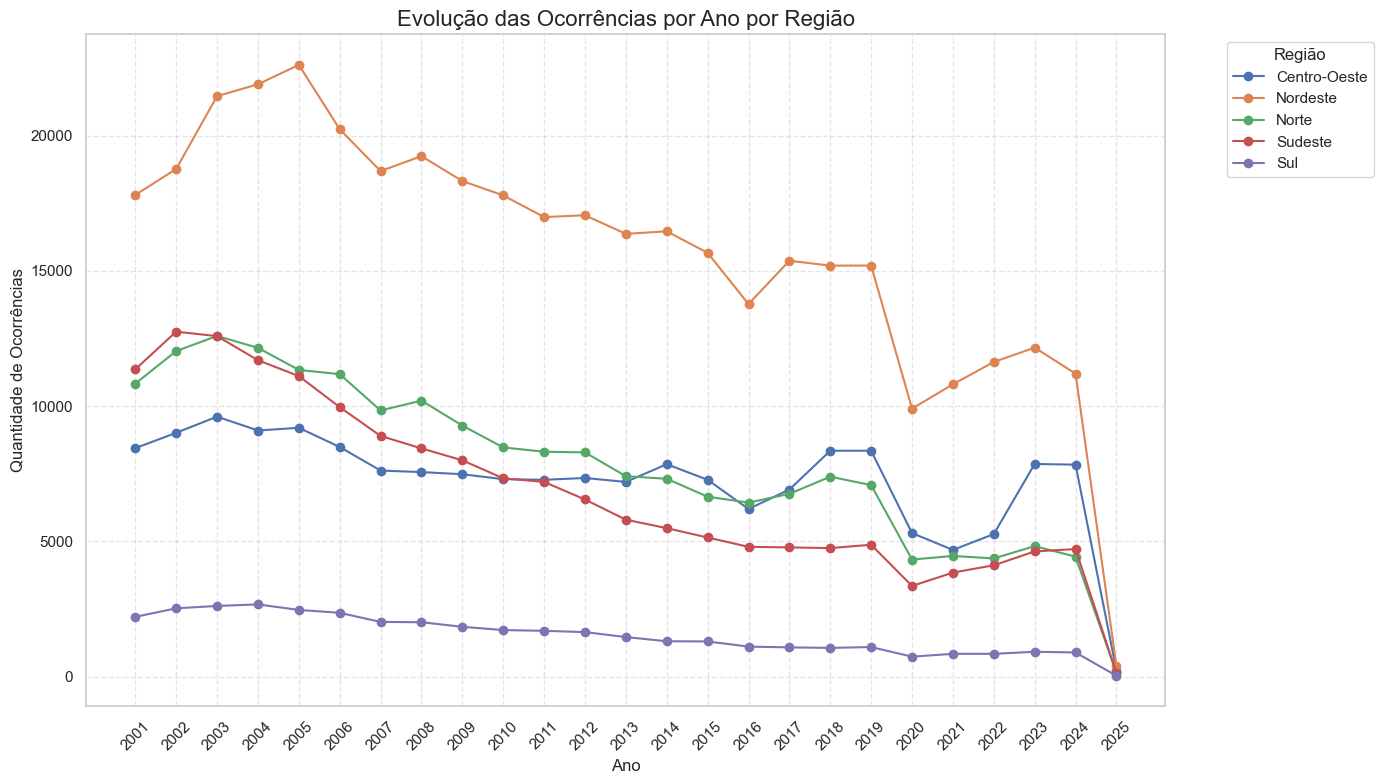

In [46]:

# Criar DataFrame de estados com regiões
df_estados = pd.DataFrame(dados_est)

# Adicionar a coluna de região ao DataFrame de dados com base no estado
df_dados_estado = df_dados.merge(df_estados[['id', 'sigla', 'regiao']], left_on='SG_UF_NOT', right_on='id', how='left')

# Agrupar por ano e região (agora sem separar por estado)
dados_agrupados_regiao = df_dados_estado.groupby(['NU_ANO', 'regiao']).size().reset_index(name='quantidade')

# Obter lista única de regiões
regioes = dados_agrupados_regiao['regiao'].unique()

# Criar um gráfico de linha para todos os dados por região
fig, ax = plt.subplots(figsize=(14, 8))

# Plotar as ocorrências totais para cada região ao longo dos anos
for regiao in regioes:
    dados_regiao = dados_agrupados_regiao[dados_agrupados_regiao['regiao'] == regiao]
    ax.plot(
        dados_regiao['NU_ANO'],
        dados_regiao['quantidade'],
        marker='o',
        label=regiao
    )

# Configurar o título e rótulos dos eixos
ax.set_title('Evolução das Ocorrências por Ano por Região', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Quantidade de Ocorrências', fontsize=12)

# Melhorar a visualização
plt.xticks(dados_agrupados_regiao['NU_ANO'].unique(), rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

# Exibir legenda com as regiões
ax.legend(title="Região", bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajustar layout para evitar sobreposição
plt.tight_layout()

# Exibir o gráfico
plt.show()


## Mortalidade

### Por Ano

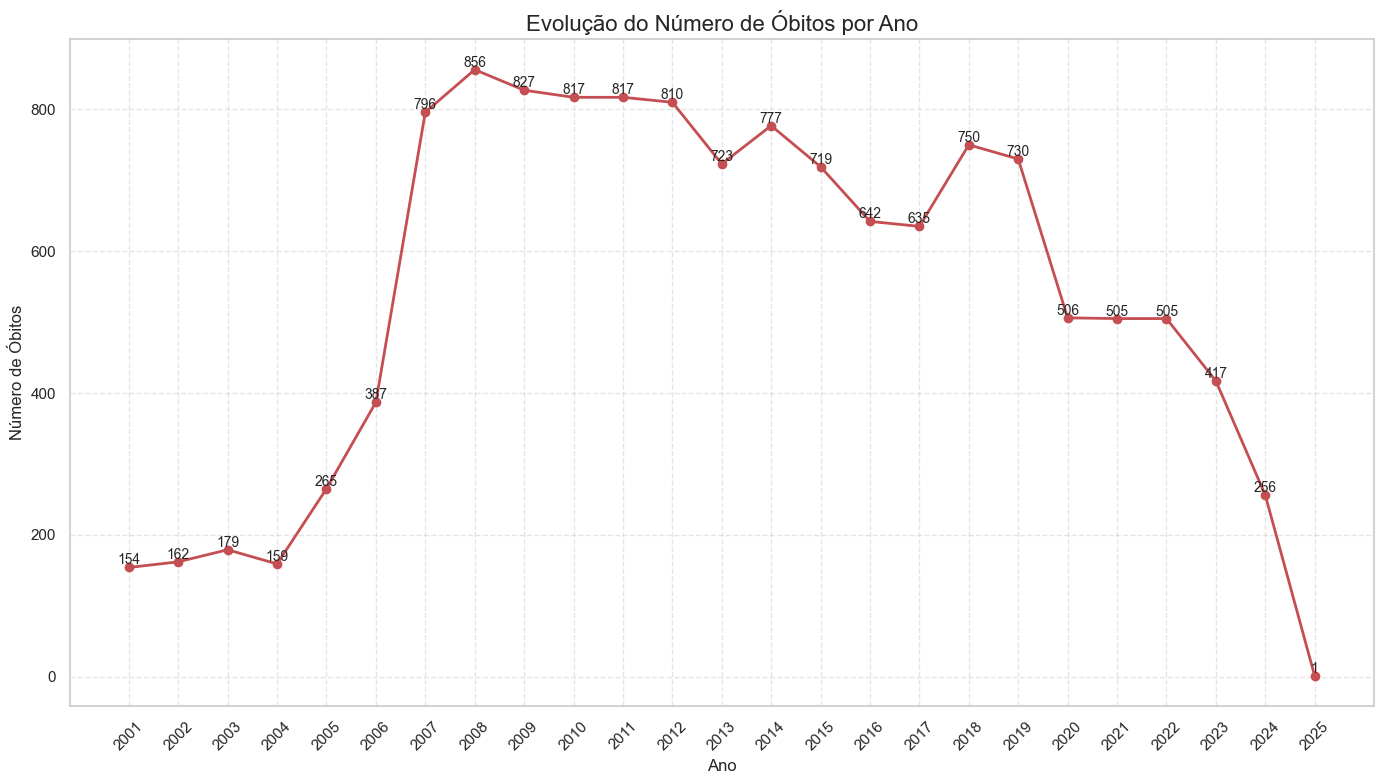

In [50]:

# Filtrar os dados para considerar apenas óbitos (TPALTA_N == 4)
df_obitos = df_dados[df_dados['TPALTA_N'] == '4']

# Agrupar os dados por ano e contar a quantidade de óbitos
dados_agrupados_obitos = df_obitos.groupby('NU_ANO').size().reset_index(name='quantidade_obitos')

# Criar o gráfico de linha
fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(
    dados_agrupados_obitos['NU_ANO'],
    dados_agrupados_obitos['quantidade_obitos'],
    marker='o',
    linestyle='-',
    linewidth=2,
    color='r'  # Cor vermelha para óbitos
)

# Adicionar os números de óbitos nos pontos do gráfico
for i, txt in enumerate(dados_agrupados_obitos['quantidade_obitos']):
    ax.annotate(txt, (dados_agrupados_obitos['NU_ANO'][i], dados_agrupados_obitos['quantidade_obitos'][i]),
                fontsize=10, ha='center', va='bottom')

# Configurar título e rótulos dos eixos
ax.set_title('Evolução do Número de Óbitos por Ano', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Número de Óbitos', fontsize=12)

# Melhorar a visualização
plt.xticks(dados_agrupados_obitos['NU_ANO'], rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

# Exibir o gráfico
plt.tight_layout()
plt.show()


### Por Mês 

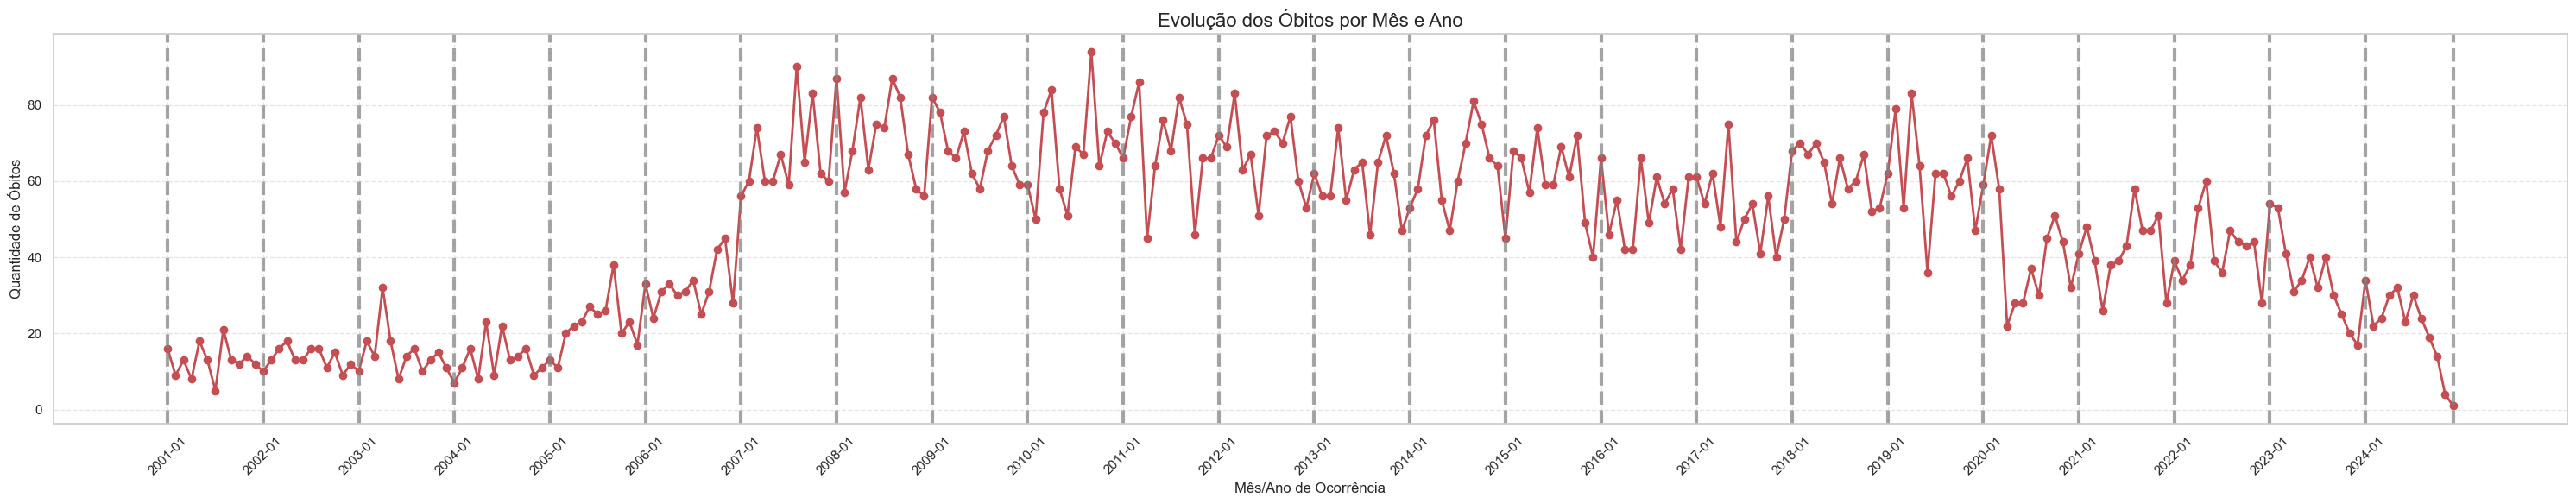

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# Filtrar os dados para considerar apenas óbitos (TPALTA_N == 4)
df_obitos = df_dados[df_dados['TPALTA_N'] == '4'].copy()  # Usar .copy() para evitar o aviso

# Converter a coluna DT_NOTIFIC para datetime
df_obitos.loc[:, "DT_NOTIFIC"] = pd.to_datetime(df_obitos["DT_NOTIFIC"], format='%Y%m%d', errors='coerce')

# Criar uma nova coluna no formato "AAAA-MM"
df_obitos.loc[:, "ANO_MES"] = df_obitos["DT_NOTIFIC"].dt.to_period("M").astype(str)

# Agrupar os dados por "ANO_MES" e contar a quantidade de óbitos
dados_agrupados_obitos = df_obitos.groupby("ANO_MES").size().reset_index(name="quantidade_obitos")

# Detectar mudanças de ano para adicionar linhas verticais
dados_agrupados_obitos["ANO"] = dados_agrupados_obitos["ANO_MES"].str[:4]
anos_unicos = dados_agrupados_obitos["ANO"].drop_duplicates().index

# Plotar o gráfico de linha com todos os pontos
fig, ax = plt.subplots(figsize=(30, 6))

ax.plot(
    dados_agrupados_obitos["ANO_MES"],
    dados_agrupados_obitos["quantidade_obitos"],
    marker='o',
    linestyle='-',
    linewidth=2,
    color='r'  # Cor vermelha para óbitos
)

# Configurar título e rótulos dos eixos
ax.set_title("Evolução dos Óbitos por Mês e Ano", fontsize=16)
ax.set_xlabel("Mês/Ano de Ocorrência", fontsize=12)
ax.set_ylabel("Quantidade de Óbitos", fontsize=12)

# Ajustar os ticks (marcadores) do eixo X para exibir de 6 em 6 meses (somente legenda)
xticks = dados_agrupados_obitos["ANO_MES"][::12]  # Seleciona a cada 12 meses (1 ano)
ax.set_xticks(xticks)
ax.set_xticklabels(xticks, rotation=45)

# Adicionar linhas verticais nos inícios de cada ano
for ano_idx in anos_unicos:
    ax.axvline(x=ano_idx, color='gray', linestyle='--', linewidth=3, alpha=0.7)

# Exibir grid para melhor visualização
plt.grid(True, linestyle='--', alpha=0.5)

# Ajustar a disposição do layout
plt.tight_layout()

# Exibir o gráfico
plt.show()


### Por Estado

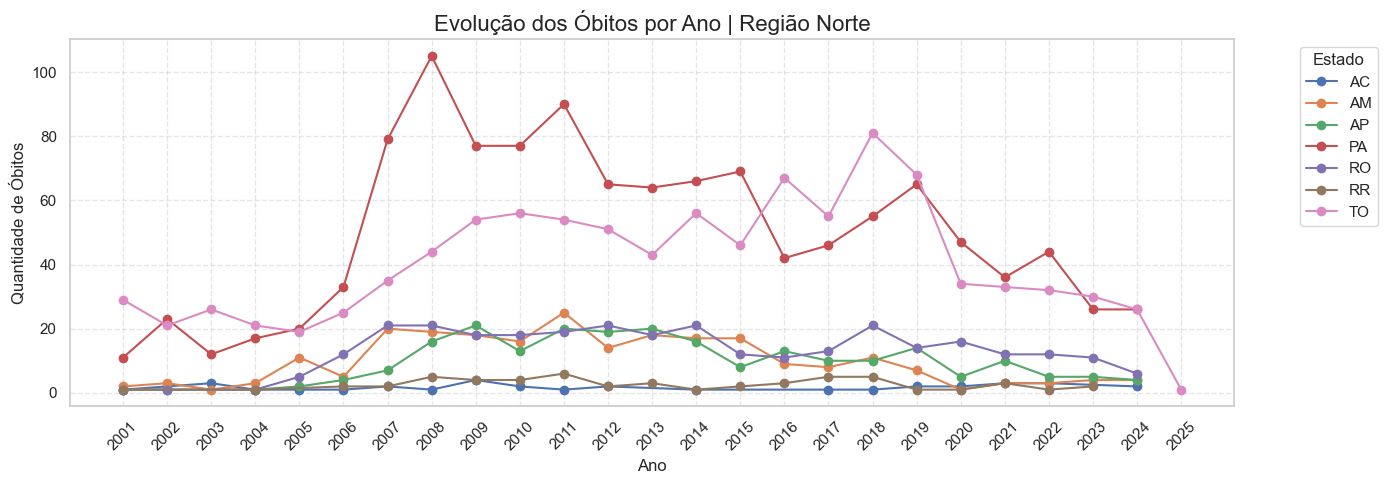

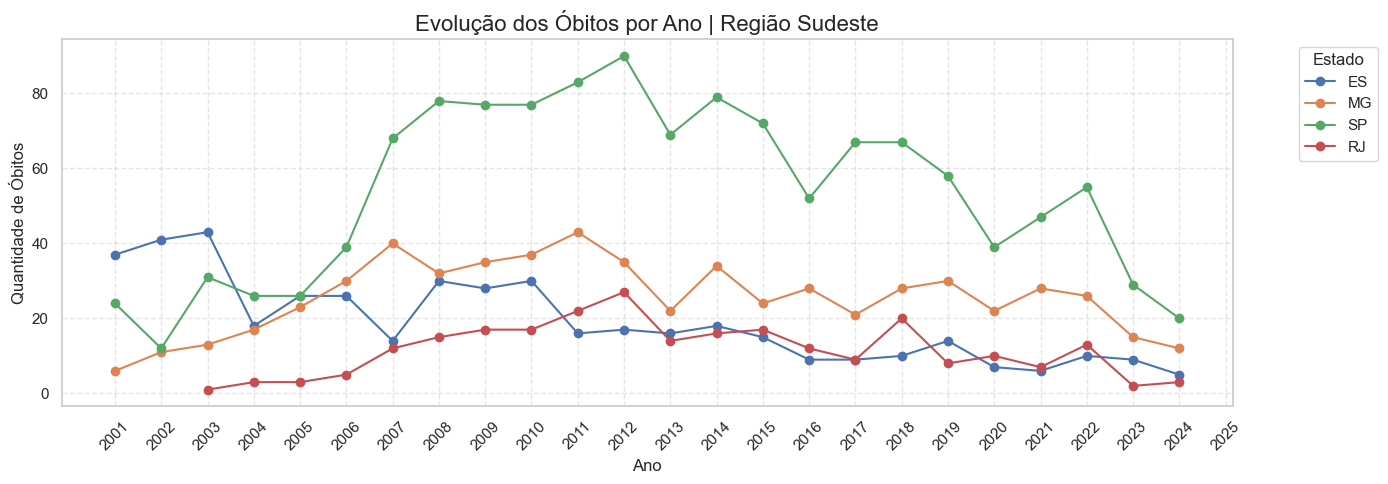

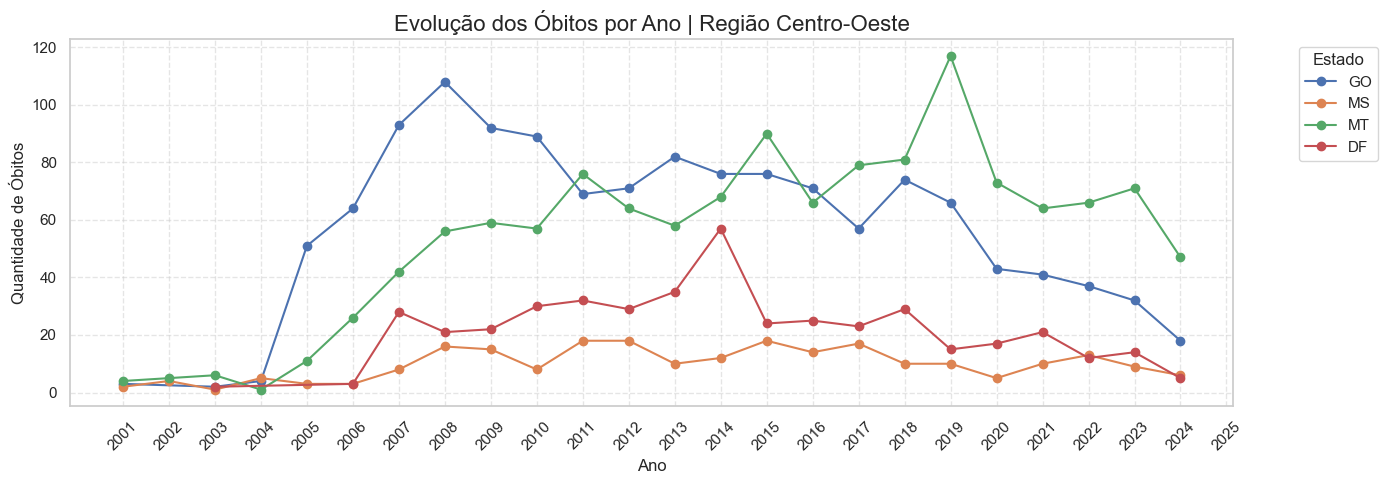

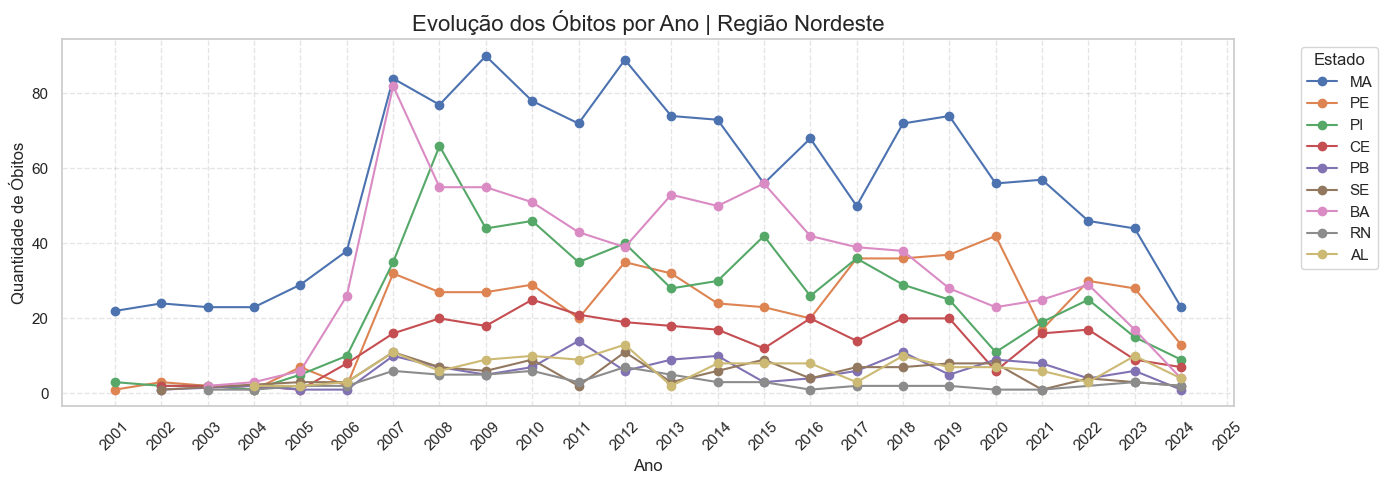

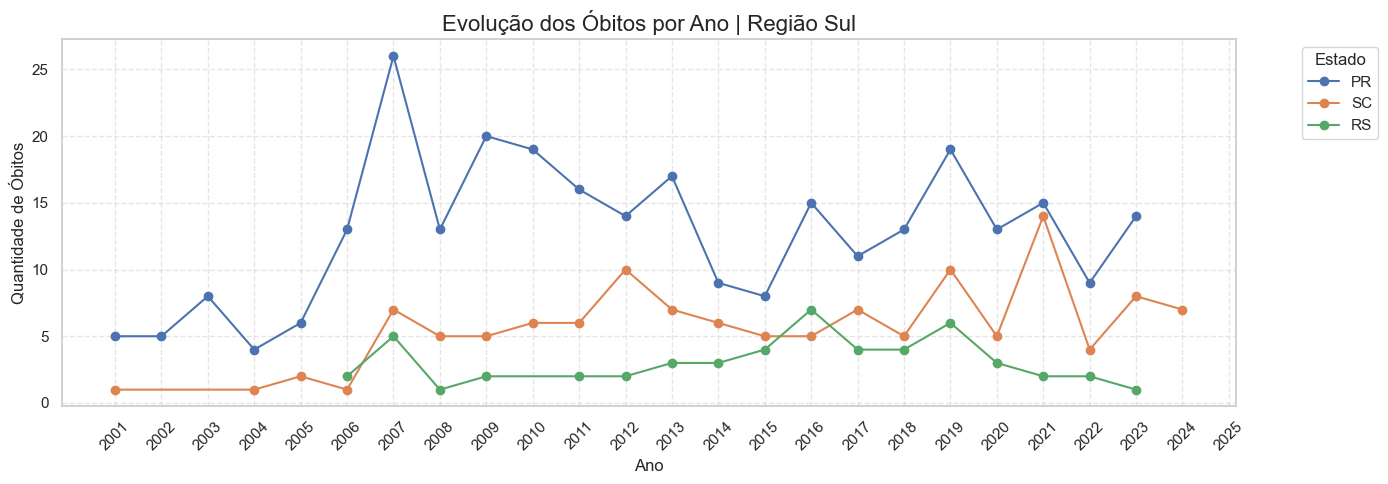

In [53]:
# Filtrar os dados para considerar apenas óbitos (TPALTA_N == 4)
df_obitos = df_dados[df_dados['TPALTA_N'] == '4'].copy()  # Usar .copy() para evitar o aviso

# Criar DataFrame de estados
df_estados = pd.DataFrame(dados_est)

# Adicionar ao DataFrame original uma coluna para os nomes dos estados e regiões
df_dados_estado = df_obitos.merge(df_estados[['id', 'sigla', 'regiao']], left_on='SG_UF_NOT', right_on='id', how='left')

# Agrupar por ano, estado e região para óbitos
dados_agrupados_obitos = df_dados_estado.groupby(['NU_ANO', 'sigla', 'regiao']).size().reset_index(name='quantidade_obitos')

# Obter lista única de regiões
regioes = dados_agrupados_obitos['regiao'].unique()

# Criar gráficos de linha para cada região
for regiao in regioes:
    fig, ax = plt.subplots(figsize=(14, 5))

    dados_regiao = dados_agrupados_obitos[dados_agrupados_obitos['regiao'] == regiao]

    for estado in dados_regiao['sigla'].unique():
        dados_estado = dados_regiao[dados_regiao['sigla'] == estado]
        ax.plot(
            dados_estado['NU_ANO'],
            dados_estado['quantidade_obitos'],
            marker='o',
            label=estado
        )

    # Configurar títulos e rótulos
    ax.set_title(f'Evolução dos Óbitos por Ano | Região {regiao}', fontsize=16)
    ax.set_xlabel('Ano', fontsize=12)
    ax.set_ylabel('Quantidade de Óbitos', fontsize=12)

    # Melhorar a visualização
    plt.xticks(dados_agrupados_obitos['NU_ANO'].unique(), rotation=45)
    plt.grid(True, linestyle='--', alpha=0.5)
    ax.legend(title="Estado", bbox_to_anchor=(1.05, 1), loc='upper left')

    # Ajustar o layout para evitar sobreposição
    plt.tight_layout()

    # Exibir o gráfico para a região atual
    plt.show()


### Por Região

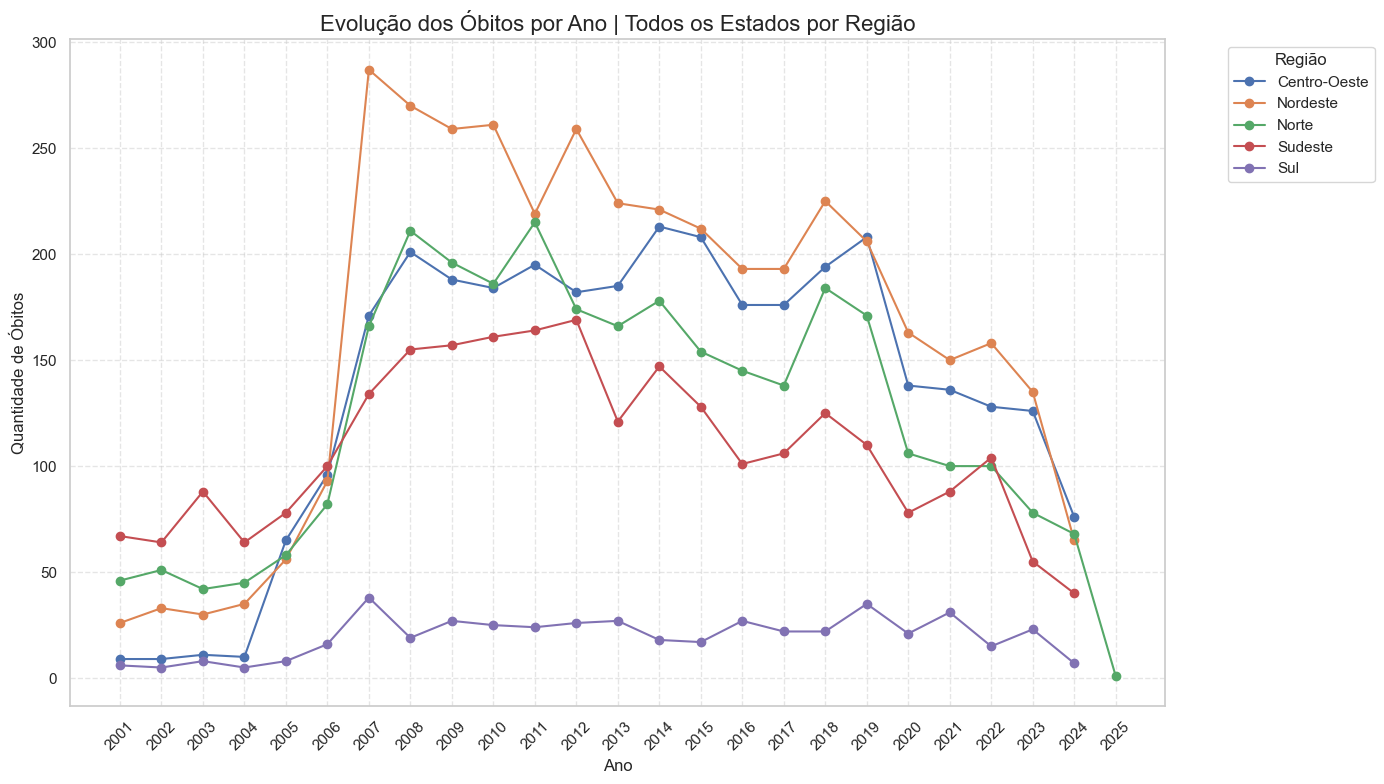

In [54]:
# Filtrar os dados para considerar apenas óbitos (TPALTA_N == 4)
df_obitos = df_dados[df_dados['TPALTA_N'] == '4'].copy()  # Usar .copy() para evitar o aviso

# Criar DataFrame de estados
df_estados = pd.DataFrame(dados_est)

# Adicionar ao DataFrame original uma coluna para os nomes dos estados e regiões
df_dados_estado = df_obitos.merge(df_estados[['id', 'sigla', 'regiao']], left_on='SG_UF_NOT', right_on='id', how='left')

# Agrupar por ano e região para óbitos
dados_agrupados_obitos = df_dados_estado.groupby(['NU_ANO', 'regiao']).size().reset_index(name='quantidade_obitos')

# Obter lista única de regiões
regioes = dados_agrupados_obitos['regiao'].unique()

# Criar gráfico de linha para cada região, com a soma dos óbitos por ano
fig, ax = plt.subplots(figsize=(14, 8))

# Para cada região, plotar os dados de óbitos
for regiao in regioes:
    dados_regiao = dados_agrupados_obitos[dados_agrupados_obitos['regiao'] == regiao]
    ax.plot(
        dados_regiao['NU_ANO'],
        dados_regiao['quantidade_obitos'],
        marker='o',
        label=regiao
    )

# Configurar título e rótulos
ax.set_title('Evolução dos Óbitos por Ano | Todos os Estados por Região', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Quantidade de Óbitos', fontsize=12)

# Melhorar a visualização
plt.xticks(dados_agrupados_obitos['NU_ANO'].unique(), rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
ax.legend(title="Região", bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajustar o layout para evitar sobreposição
plt.tight_layout()

# Exibir o gráfico para as regiões
plt.show()


## Associação com dados IBGE

In [56]:
# Carregar os dados IBGE (SIDRA)
path_dados_ibge = os.path.join('.', 'data', 'IBGE','populacao_municipios.csv')
dados_ibge = pd.read_csv(path_dados_ibge)

In [57]:
dados_ibge.info()
dados_ibge.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150950 entries, 0 to 150949
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   ano             150950 non-null  int64 
 1   id_municipio    150950 non-null  int64 
 2   nome_municipio  150950 non-null  object
 3   sigla_uf        150950 non-null  object
 4   pessoas         150950 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 5.8+ MB


,ano,id_municipio,nome_municipio,sigla_uf,pessoas
0,1970,1100106,Guajará-Mirim,RO,27016
1,1970,1100205,Porto Velho,RO,84048
2,1970,1200104,Brasiléia,AC,12311
3,1970,1200203,Cruzeiro do Sul,AC,43584
4,1970,1200302,Feijó,AC,15768


### Agrupar por ano e somar o número de pessoas

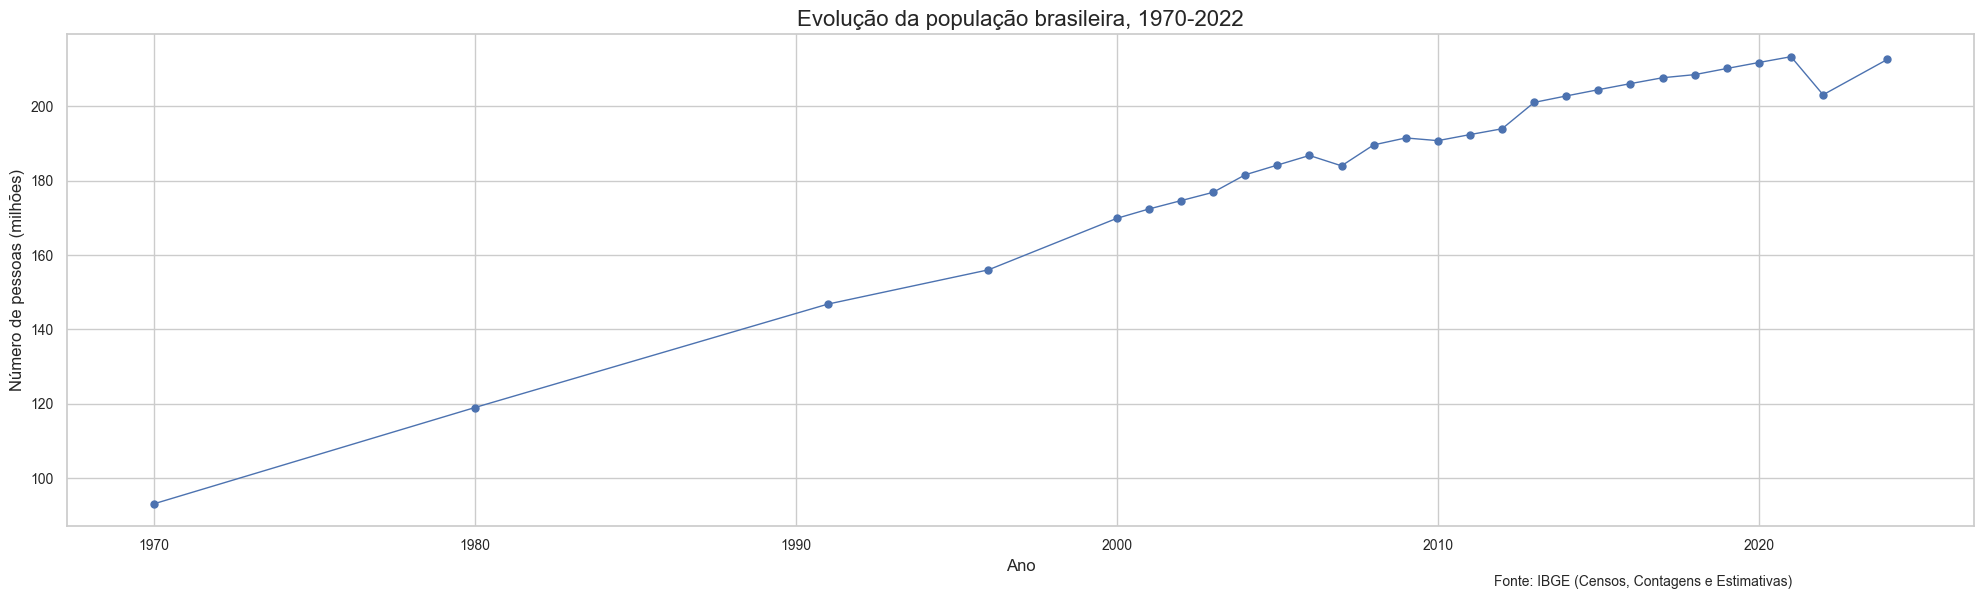

In [58]:

# Agrupar por ano e somar o número de pessoas
dados_agrupados = (
    dados_ibge.groupby("ano", as_index=False)
    .agg(n_pessoas=("pessoas", "sum"))
)

# Configurar o estilo do gráfico
sns.set_theme(style="whitegrid")

# Criar o gráfico
plt.figure(figsize=(20, 6))
plt.plot(dados_agrupados["ano"], dados_agrupados["n_pessoas"] / 1_000_000, 
         linewidth=1, marker="o", markersize=5)

# Personalizar o gráfico
plt.title("Evolução da população brasileira, 1970-2022", fontsize=16)
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Número de pessoas (milhões)", fontsize=12)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))  # Formatar os números no eixo Y
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.figtext(0.9, 0.01, "Fonte: IBGE (Censos, Contagens e Estimativas)", fontsize=10, ha="right")

# Exibir o gráfico
plt.tight_layout()
plt.show()


### por ano e por estado

In [59]:
# Filtrar os dados para considerar apenas óbitos (TPALTA_N == 4)
df_obitos = df_dados[df_dados['TPALTA_N'] == '4'].copy()  # Usar .copy() para evitar o aviso

# Criar DataFrame de estados
df_estados = pd.DataFrame(dados_est)

# Adicionar ao DataFrame original uma coluna para os nomes dos estados e regiões
df_dados_estado = df_obitos.merge(df_estados[['id', 'sigla', 'regiao']], left_on='SG_UF_NOT', right_on='id', how='left')

# Agrupar os dados de população por ano e estado
df_populacao_estado_ano = dados_ibge.groupby(['ano', 'sigla_uf'])['pessoas'].sum().reset_index()

# Renomear a coluna 'sigla_uf' para 'sigla' para facilitar o merge
df_populacao_estado_ano.rename(columns={'sigla_uf': 'sigla'}, inplace=True)

# Agrupar os dados de óbitos por ano e estado
df_obitos_agrupados = df_dados_estado.groupby(['NU_ANO', 'sigla']).size().reset_index(name='total_obitos')

# Fazer o merge dos dados de óbitos agrupados com os dados de população por ano e estado
df_obitos_populacao_ano = df_obitos_agrupados.merge(
    df_populacao_estado_ano,
    left_on=['NU_ANO', 'sigla'],
    right_on=['ano', 'sigla'],
    how='left'
)

# Calcular a taxa de mortalidade por 100.000 habitantes (opcional)
df_obitos_populacao_ano['taxa_mortalidade'] = (df_obitos_populacao_ano['total_obitos'] / df_obitos_populacao_ano['pessoas']) * 100000

# Exibir o DataFrame resultante
print(df_obitos_populacao_ano)

     NU_ANO sigla  total_obitos     ano     pessoas  taxa_mortalidade
0      2001    AC             1  2001.0    574355.0          0.174108
1      2001    AM             2  2001.0   2900240.0          0.068960
2      2001    AP             1  2001.0    498735.0          0.200507
3      2001    ES            37  2001.0   3155016.0          1.172736
4      2001    GO             3  2001.0   5116462.0          0.058634
..      ...   ...           ...     ...         ...               ...
602    2024    SC             7  2024.0   8058441.0          0.086865
603    2024    SE             2  2024.0   2291077.0          0.087295
604    2024    SP            20  2024.0  45973194.0          0.043504
605    2024    TO            26  2024.0   1577342.0          1.648343
606    2025    TO             1     NaN         NaN               NaN

[607 rows x 6 columns]


### Preencher dados faltantes de população utilizando interpolação

In [61]:

# Supondo que você já tenha os DataFrames df_obitos_estado_populacao e df_estados
# df_obitos_estado_populacao contém as colunas: NU_ANO, sigla, total_obitos, pessoas
# df_estados contém as colunas: sigla, regiao

# Preencher dados faltantes de população utilizando interpolação
df_obitos_estado_populacao_interpolado = df_obitos_populacao_ano.copy()

# Interpolação linear para preencher os valores de 'pessoas' nulos
df_obitos_estado_populacao_interpolado['pessoas'] = df_obitos_estado_populacao_interpolado.groupby('sigla')['pessoas'].transform(
    lambda x: x.interpolate(method='linear')
)

# Filtrar os dados válidos após interpolação
df_obitos_estado_populacao_interpolado_validos = df_obitos_estado_populacao_interpolado.dropna(subset=['pessoas'])

# Calcular a taxa de óbitos após interpolação
df_obitos_estado_populacao_interpolado_validos['taxa_obitos_100k'] = (
    df_obitos_estado_populacao_interpolado_validos['total_obitos'] / df_obitos_estado_populacao_interpolado_validos['pessoas']
) * 100000

# Adicionar a região ao DataFrame
df_obitos_estado_populacao_interpolado_validos = df_obitos_estado_populacao_interpolado_validos.merge(
    df_estados[['sigla', 'regiao']],  # Supondo que você tenha a coluna 'regiao'
    on='sigla',
    how='left'
)

# Verificar o DataFrame final após interpolação
print(df_obitos_estado_populacao_interpolado_validos.head())



   NU_ANO sigla  total_obitos     ano    pessoas  taxa_mortalidade  \
0    2001    AC             1  2001.0   574355.0          0.174108   
1    2001    AM             2  2001.0  2900240.0          0.068960   
2    2001    AP             1  2001.0   498735.0          0.200507   
3    2001    ES            37  2001.0  3155016.0          1.172736   
4    2001    GO             3  2001.0  5116462.0          0.058634   

   taxa_obitos_100k        regiao  
0          0.174108         Norte  
1          0.068960         Norte  
2          0.200507         Norte  
3          1.172736       Sudeste  
4          0.058634  Centro-Oeste  


### Obter lista única de regiões

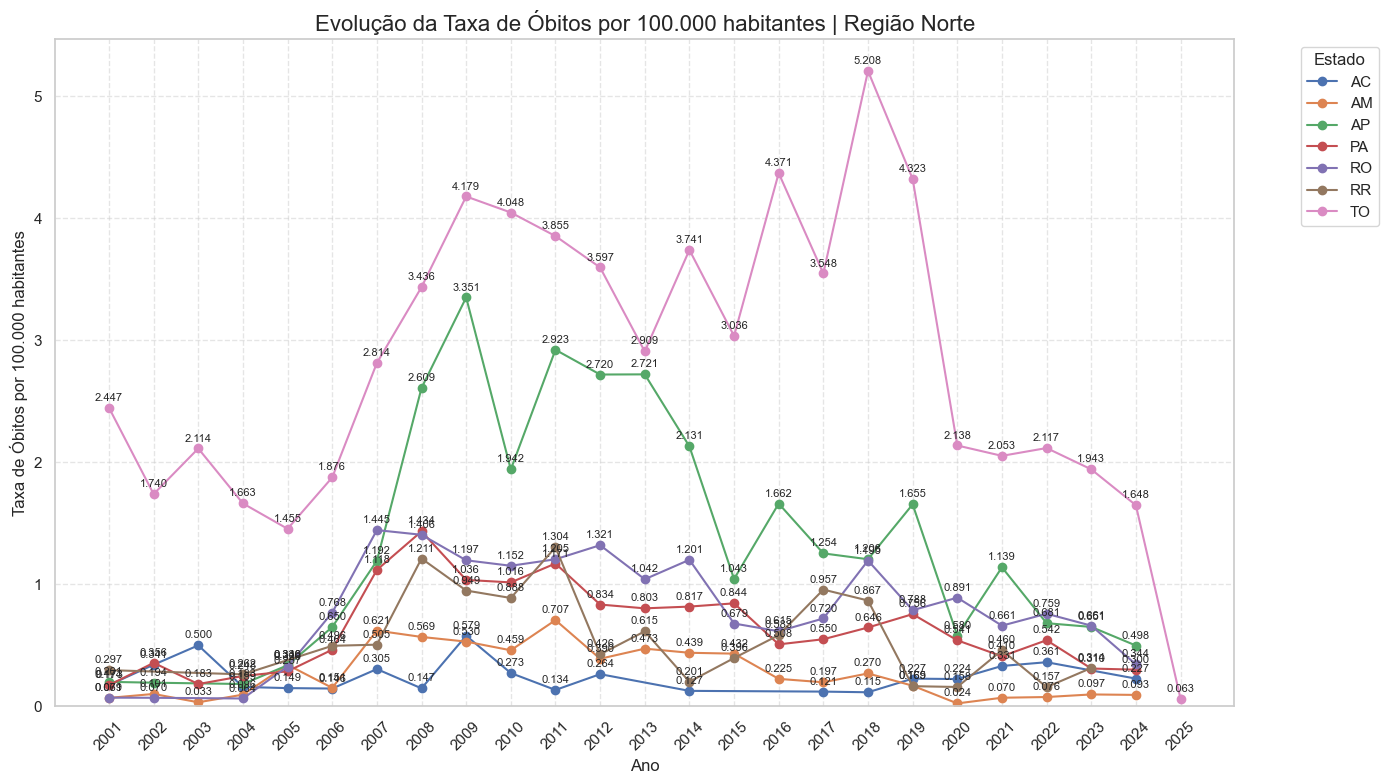

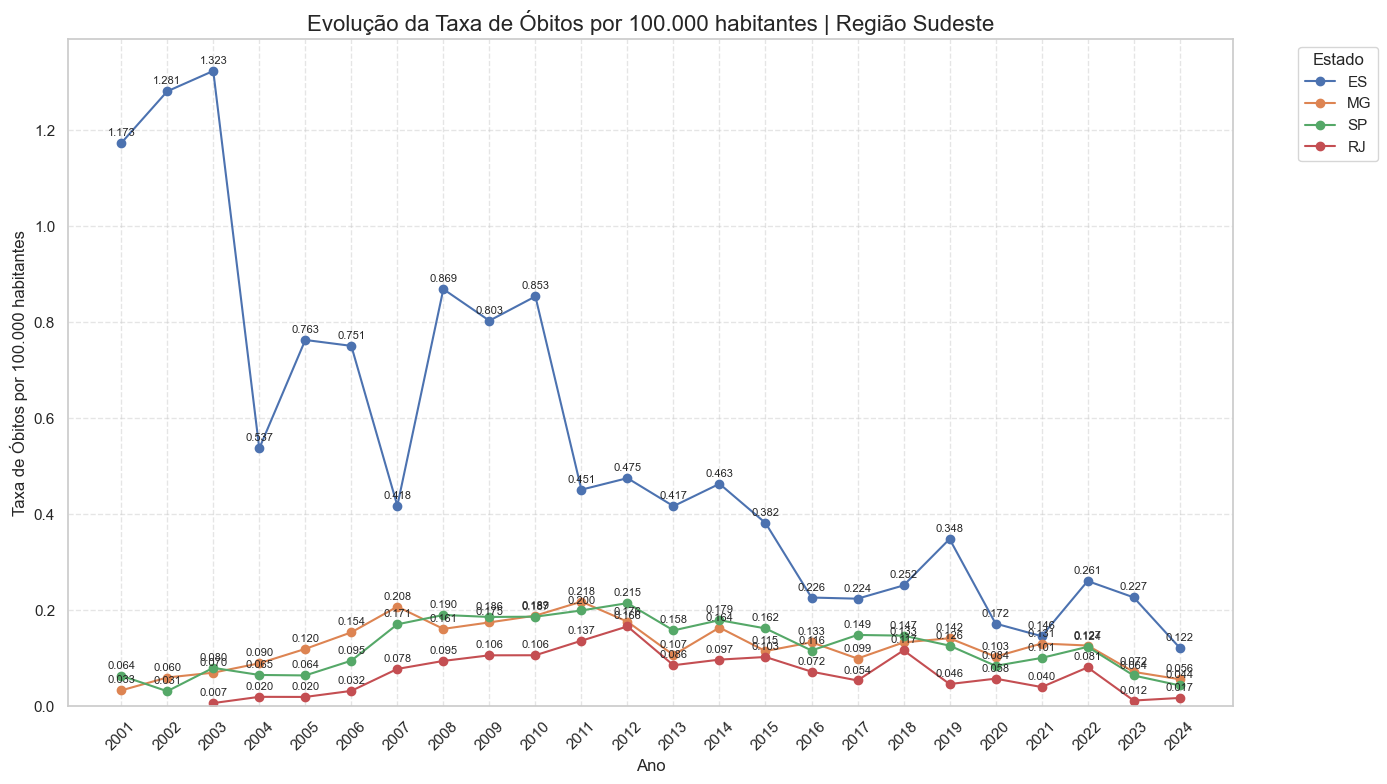

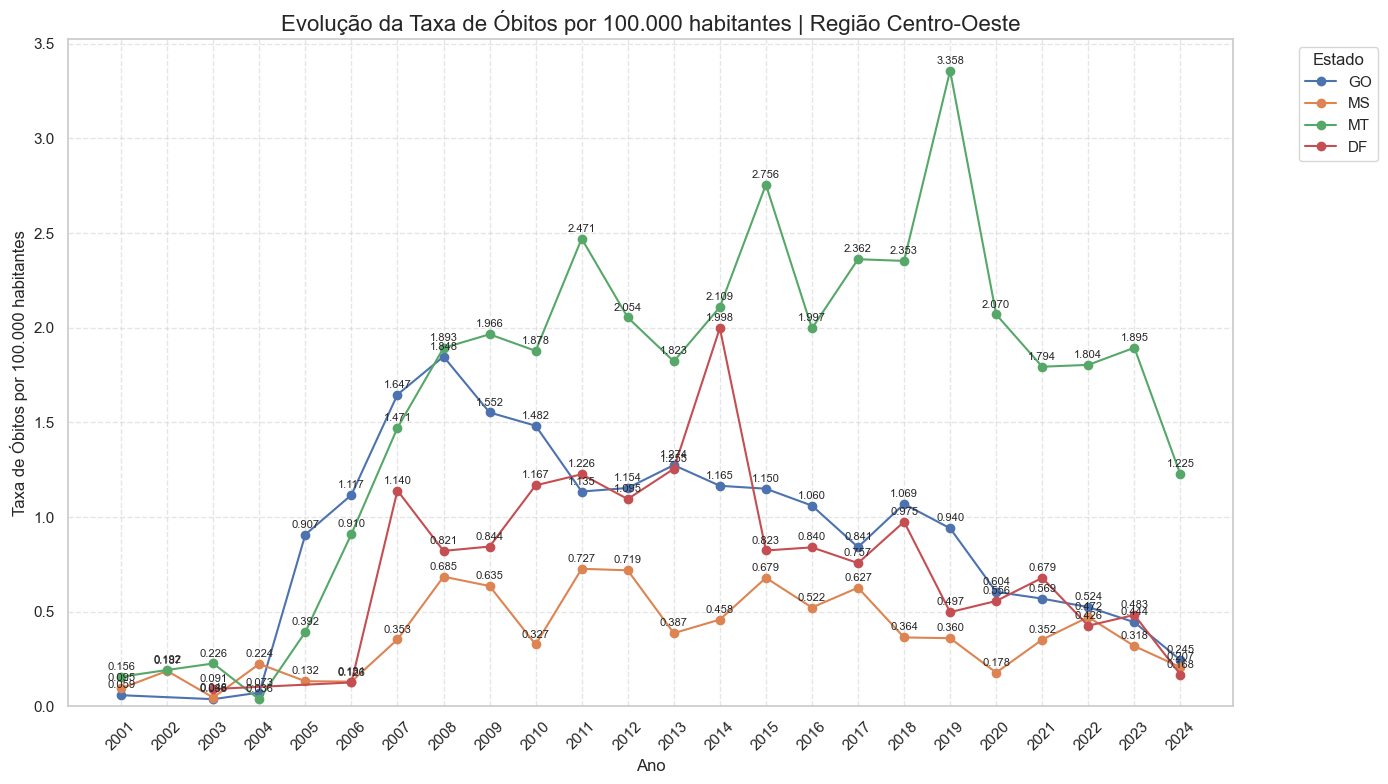

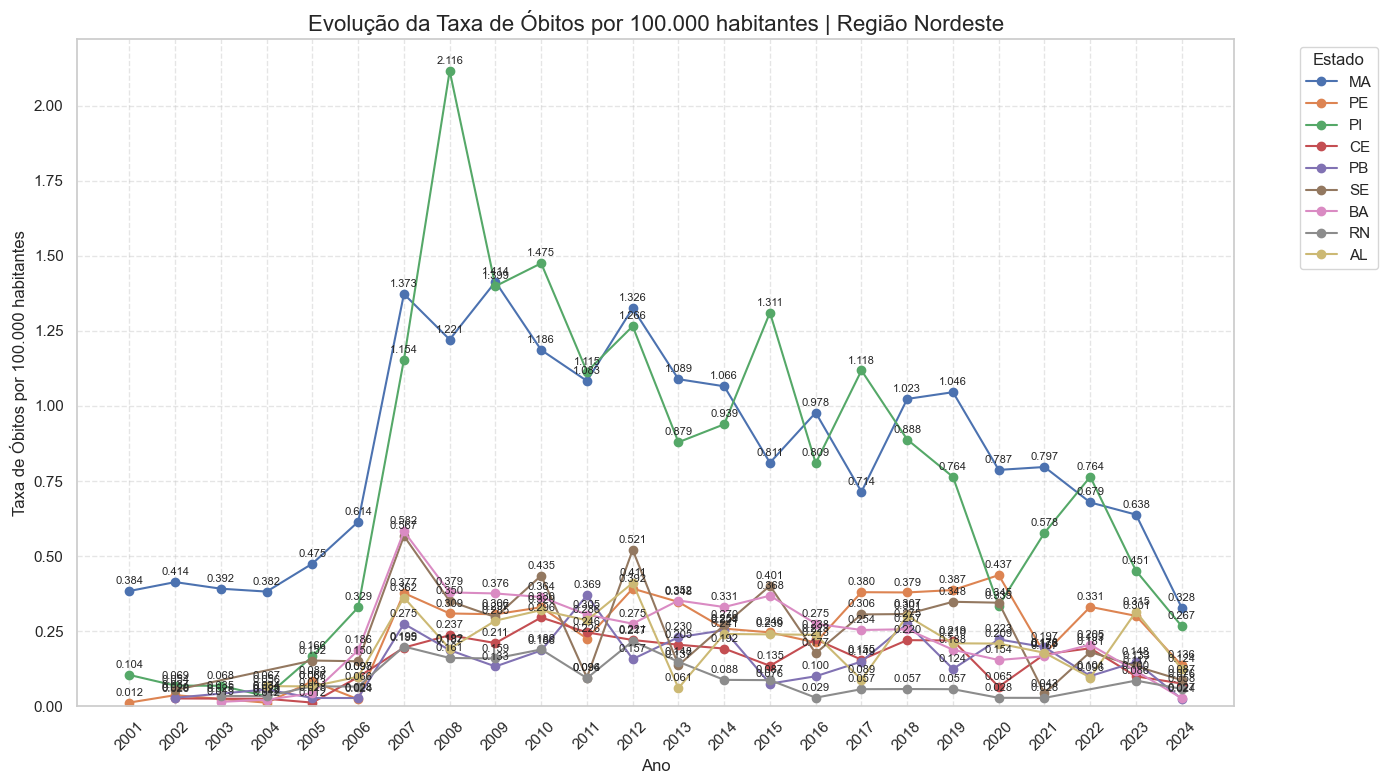

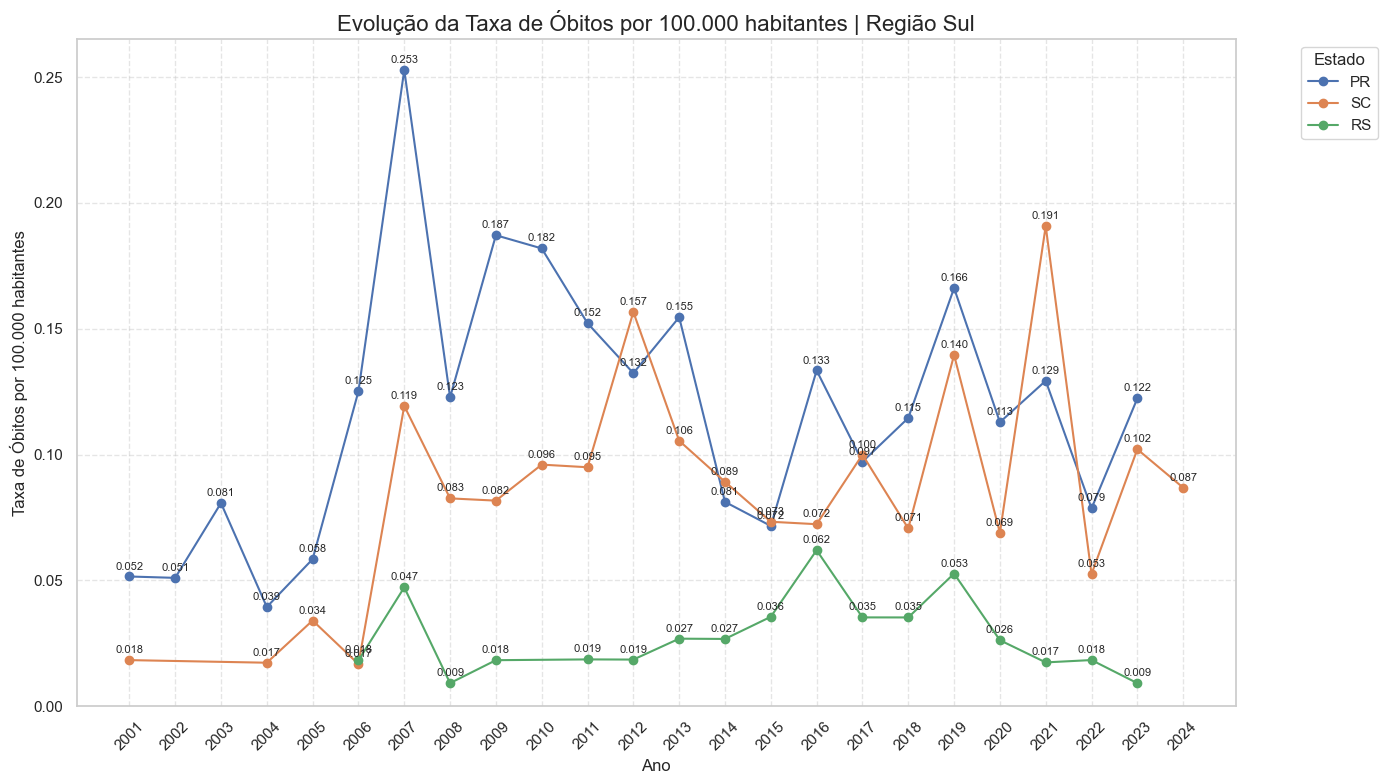

In [62]:
# Obter lista única de regiões
regioes = df_obitos_estado_populacao_interpolado_validos['regiao'].unique()

# Gerar um gráfico para cada região
for regiao in regioes:
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Filtrar dados da região atual
    dados_regiao = df_obitos_estado_populacao_interpolado_validos[df_obitos_estado_populacao_interpolado_validos['regiao'] == regiao]
    
    # Garantir que dados não nulos sejam considerados para a taxa de óbitos
    dados_regiao = dados_regiao.dropna(subset=['taxa_obitos_100k'])
    
    # Plotar a taxa de óbitos por estado dentro da região
    for estado in dados_regiao['sigla'].unique():
        dados_estado = dados_regiao[dados_regiao['sigla'] == estado]
        
        # Plotar a taxa de óbitos por 100.000 habitantes para cada estado
        ax.plot(
            dados_estado['NU_ANO'],
            dados_estado['taxa_obitos_100k'],
            marker='o',
            label=estado
        )
    
    # Configurar títulos e rótulos
    ax.set_title(f'Evolução da Taxa de Óbitos por 100.000 habitantes | Região {regiao}', fontsize=16)
    ax.set_xlabel('Ano', fontsize=12)
    ax.set_ylabel('Taxa de Óbitos por 100.000 habitantes', fontsize=12)
    
    # Adicionar valores nos pontos do gráfico, ajustando a posição para evitar sobreposição
    for _, row in dados_regiao.iterrows():
        ax.annotate(f'{row["taxa_obitos_100k"]:.3f}', 
                    (row['NU_ANO'], row['taxa_obitos_100k']),
                    textcoords="offset points",
                    xytext=(0, 5),
                    ha='center',
                    fontsize=8)
    
    # Melhorar a visualização
    plt.xticks(dados_regiao['NU_ANO'].unique(), rotation=45)
    ax.set_ylim(bottom=0)  # Garantir que o eixo Y comece de 0
    plt.grid(True, linestyle='--', alpha=0.5)
    ax.legend(title="Estado", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Ajustar layout
    plt.tight_layout()

    # Exibir o gráfico
    plt.show()


# Redes neurais


#### WMAPE

WMAPE (Weighted Mean Absolute Percentage Error) é um indicador que mede a precisão de previsões de demanda. É uma variação do MAPE (Mean Absolute Percentage Error).

In [64]:
def wmape(y_true, y_pred):
    return np.abs(y_true - y_pred).sum() / np.abs(y_true).sum()

### Agrupar por "ANO_MES" e contar as ocorrências

In [166]:

# Certifique-se de que a coluna DT_NOTIFIC foi convertida para datetime
df_dados["DT_NOTIFIC"] = pd.to_datetime(df_dados["DT_NOTIFIC"], format='%Y%m%d', errors='coerce')

# Criar uma nova coluna no formato "AAAA-MM"
df_dados["ANO_MES"] = df_dados["DT_NOTIFIC"].dt.to_period("M").astype(str)

# Agrupar por "ANO_MES" e contar as ocorrências
dados_agrupados = df_dados.groupby("ANO_MES").size().reset_index(name="quantidade")

# Exibir os primeiros registros para verificar
print(dados_agrupados.head())



   ANO_MES  quantidade
0  2001-01        3702
1  2001-02        4002
2  2001-03        4727
3  2001-04        4190
4  2001-05        4703


### Uso dos modelos NBEATS, NHITS

Seed set to 1


Registros no conjunto de teste: 60


Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.5 M  | train
-------------------------------------------------------
2.5 M     Trainable params
3.5 K     Non-trainable params
2.5 M     Total params
9.948     Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode


Epoch 999: 100%|██████████| 1/1 [00:00<00:00,  4.64it/s, v_num=6, train_loss_step=7.820, train_loss_epoch=7.820]  

`Trainer.fit` stopped: `max_steps=1000` reached.


...

Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 24.85it/s]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 195.62it/s]

d:\python\data_health\venv_health\Lib\site-packages\neuralforecast\core.py:214: FutureWarning: In a future version the predictions will have the id as a column. You can set the `NIXTLA_ID_AS_COL` environment variable to adopt the new behavior and to suppress this warning.
  warnings.warn(



Datas nas previsões:
          ds
0 2020-03-01
1 2020-04-01
2 2020-05-01
3 2020-06-01
4 2020-07-01
Previsões atribuídas:
            ds     y  y_pred_NBEATS  y_pred_NHITS
275 2023-12-01  2035            NaN           NaN
276 2024-01-01  2490            NaN           NaN
277 2024-02-01  2519            NaN           NaN
278 2024-03-01  2329            NaN           NaN
279 2024-04-01  2593            NaN           NaN
280 2024-05-01  2514            NaN           NaN
281 2024-06-01  2477            NaN           NaN
282 2024-07-01  2553            NaN           NaN
283 2024-08-01  2601            NaN           NaN
284 2024-09-01  2574            NaN           NaN
285 2024-10-01  2657            NaN           NaN
286 2024-11-01  2087            NaN           NaN
287 2024-12-01  1701            NaN           NaN
288 2025-01-01   915            NaN           NaN
289 2025-02-01     3            NaN           NaN


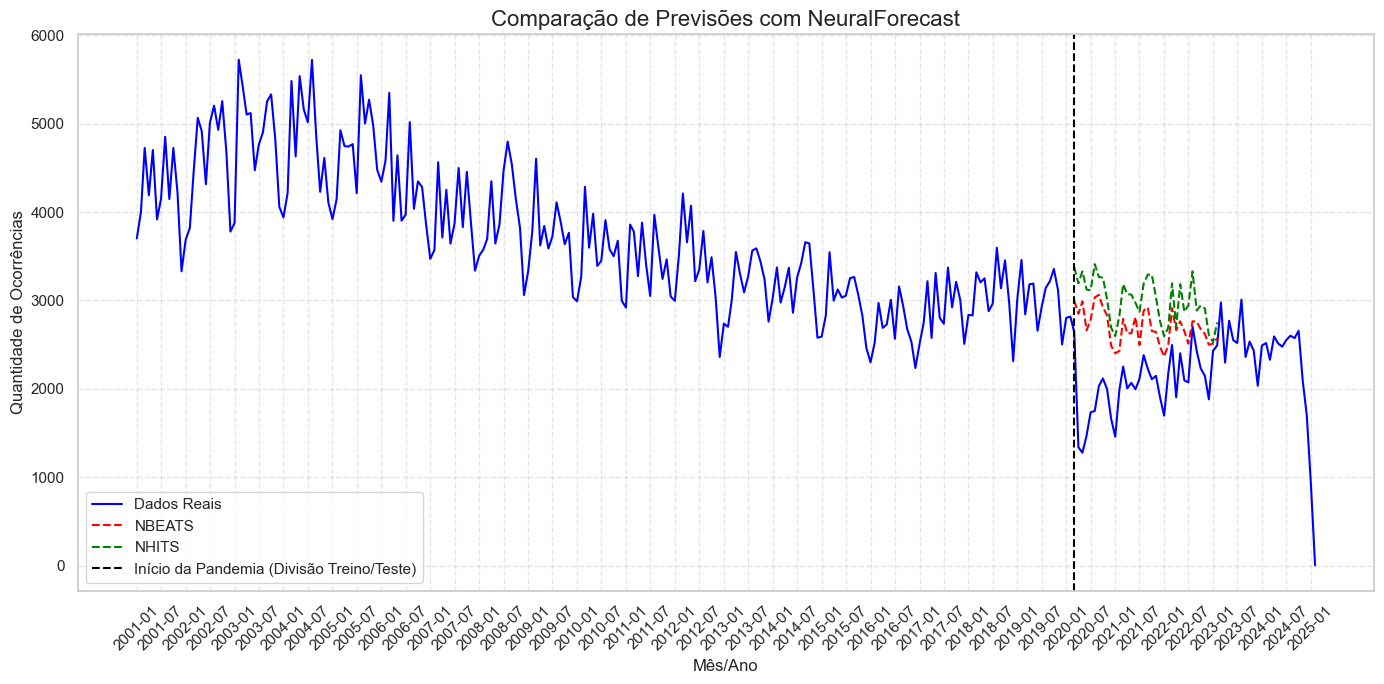

In [153]:
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS, NHITS
from neuralforecast.losses.pytorch import MAE

# Formatação para o NeuralForecast
df_nf = pd.DataFrame({
    'unique_id': 'serie',  # Identificador único da série
    'ds': pd.to_datetime(dados_agrupados["ANO_MES"]),  # Coluna com as datas
    'y': dados_agrupados["quantidade"]  # Coluna com os valores
})

# Divisão dos dados em treino e teste
split_date = pd.Timestamp('2020-03-01')
df_train = df_nf[df_nf['ds'] < split_date].copy()
df_test = df_nf[df_nf['ds'] >= split_date].copy()

# Verificando o número de registros no conjunto de teste
print(f"Registros no conjunto de teste: {len(df_test)}")  # Deve ser 12

# Modelos a serem usados
modelos = [
    NBEATS(input_size=12, h=36, loss=MAE()),  # Horizon estendido para 36 meses
    NHITS(input_size=12, h=36, loss=MAE())   # Horizon estendido para 36 meses
]

# Configuração e treinamento do NeuralForecast
nf = NeuralForecast(models=modelos, freq='MS')  # Frequência mensal
nf.fit(df_train)

# Previsões para todo o período (horizonte de previsão)
forecast_train_test = nf.predict(df_train)

# Resetando o índice do DataFrame de previsões para facilitar a atribuição
forecast_train_test.reset_index(drop=True, inplace=True)

# Verifique as datas das previsões geradas
print("Datas nas previsões:")
print(forecast_train_test[['ds']].head())

# Atribuindo previsões ao DataFrame original (apenas para o horizonte de previsão)
df_predictions = forecast_train_test[['ds', 'NBEATS', 'NHITS']].copy()

# Garantindo que apenas as datas previstas sejam usadas no merge
df_merged = pd.merge(df_nf, df_predictions, on='ds', how='left')
df_merged.rename(columns={'NBEATS': 'y_pred_NBEATS', 'NHITS': 'y_pred_NHITS'}, inplace=True)

# Verificando se as previsões foram atribuídas corretamente
print("Previsões atribuídas:")
print(df_merged[['ds', 'y', 'y_pred_NBEATS', 'y_pred_NHITS']].tail(15))

# Plotar os resultados
plt.figure(figsize=(14, 7))

# Plotar dados reais
plt.plot(df_merged['ds'], df_merged['y'], label="Dados Reais", color="blue")

# Plotar as previsões dos modelos se não forem nulas
if not df_merged['y_pred_NBEATS'].isnull().all():
    plt.plot(df_merged['ds'], df_merged['y_pred_NBEATS'], label="NBEATS", color="red", linestyle="--")
if not df_merged['y_pred_NHITS'].isnull().all():
    plt.plot(df_merged['ds'], df_merged['y_pred_NHITS'], label="NHITS", color="green", linestyle="--")

# Linha vertical para indicar a divisão treino/teste
plt.axvline(split_date, color='black', linestyle='--', label="Início da Pandemia (Divisão Treino/Teste)")

# Configurações do gráfico
plt.title("Comparação de Previsões com NeuralForecast", fontsize=16)
plt.xlabel("Mês/Ano")
plt.ylabel("Quantidade de Ocorrências")
xticks = pd.date_range(df_merged['ds'].min(), df_merged['ds'].max(), freq="6MS")
plt.xticks(xticks, labels=[tick.strftime('%Y-%m') for tick in xticks], rotation=45)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


### MLP, Random Forest, XGBoost, SVR

#### Preparação dos dados

In [173]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV

# Certifique-se de que a coluna DT_NOTIFIC foi convertida para datetime
df_dados["DT_NOTIFIC"] = pd.to_datetime(df_dados["DT_NOTIFIC"], format='%Y%m%d', errors='coerce')

# Criar uma nova coluna no formato "AAAA-MM"
df_dados["ANO_MES"] = df_dados["DT_NOTIFIC"].dt.to_period("M").astype(str)

# Agrupar por "ANO_MES" e contar as ocorrências
dados_agrupados = df_dados.groupby("ANO_MES").size().reset_index(name="quantidade")

# Preparação dos Dados
dados_agrupados["ANO_MES"] = pd.to_datetime(dados_agrupados["ANO_MES"], format='%Y-%m')
dados_agrupados["ANO_MES_NUM"] = dados_agrupados["ANO_MES"].map(lambda x: x.toordinal())

# Adicionar recursos temporais (lags, médias móveis, diferença e indicadores sazonais)
dados_agrupados["LAG_1"] = dados_agrupados["quantidade"].shift(1)
dados_agrupados["LAG_2"] = dados_agrupados["quantidade"].shift(2)
dados_agrupados["LAG_3"] = dados_agrupados["quantidade"].shift(3)
dados_agrupados["MEDIA_MOVEL_3"] = dados_agrupados["quantidade"].rolling(window=3).mean()
dados_agrupados["MEDIA_MOVEL_6"] = dados_agrupados["quantidade"].rolling(window=6).mean()
dados_agrupados["DIFF"] = dados_agrupados["quantidade"].diff()
dados_agrupados["DIFF_2"] = dados_agrupados["quantidade"].diff(2)
dados_agrupados["MES"] = dados_agrupados["ANO_MES"].dt.month
dados_agrupados["TRIMESTRE"] = dados_agrupados["ANO_MES"].dt.quarter

# Remover valores NaN gerados pelos lags e outros cálculos
dados_agrupados.dropna(inplace=True)

# Variáveis independentes e dependentes
X = dados_agrupados[["ANO_MES_NUM", "LAG_1", "LAG_2", "LAG_3", "MEDIA_MOVEL_3", 
                     "MEDIA_MOVEL_6", "DIFF", "DIFF_2", "MES", "TRIMESTRE"]].values
y = dados_agrupados["quantidade"].values

# Escalonamento dos dados
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# Separar dados de treino e teste
limite_pandemia = pd.to_datetime("2020-03").toordinal()
mask_treino = X[:, 0] < limite_pandemia
mask_teste = X[:, 0] >= limite_pandemia

X_treino = X_scaled[mask_treino]
y_treino = y_scaled[mask_treino]
X_teste = X_scaled[mask_teste]
y_teste = y_scaled[mask_teste]

# Função para reverter escalonamento
def inverter_escalonamento(y_pred_scaled):
    return scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))

#### # Modelo 1: Rede Neural Melhorada

In [174]:
# Modelo 1: Rede Neural Melhorada
class ModeloNN(nn.Module):
    def __init__(self, input_size, hidden_size1=256, hidden_size2=128, hidden_size3=64):
        super(ModeloNN, self).__init__()
        # Camada de entrada com normalização em lote
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.bn1 = nn.BatchNorm1d(hidden_size1)
        self.dropout1 = nn.Dropout(0.3)
        
        # Camadas intermediárias com conexões residuais
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.bn2 = nn.BatchNorm1d(hidden_size2)
        self.dropout2 = nn.Dropout(0.3)
        
        self.fc3 = nn.Linear(hidden_size2, hidden_size3)
        self.bn3 = nn.BatchNorm1d(hidden_size3)
        self.dropout3 = nn.Dropout(0.2)
        
        # Camada de saída
        self.fc4 = nn.Linear(hidden_size3, 1)
        
        # Camada de atenção temporal
        self.attention = nn.Linear(hidden_size3, 1)
        
    def forward(self, x):
        # Camada 1 com ativação LeakyReLU
        x1 = self.fc1(x)
        x1 = self.bn1(x1)
        x1 = F.leaky_relu(x1, 0.1)
        x1 = self.dropout1(x1)
        
        # Camada 2 com ativação LeakyReLU
        x2 = self.fc2(x1)
        x2 = self.bn2(x2)
        x2 = F.leaky_relu(x2, 0.1)
        x2 = self.dropout2(x2)
        
        # Camada 3 com ativação LeakyReLU e conexão residual
        x3 = self.fc3(x2)
        x3 = self.bn3(x3)
        x3 = F.leaky_relu(x3, 0.1)
        x3 = self.dropout3(x3)
        
        # Mecanismo de atenção simplificado
        attention_weights = torch.sigmoid(self.attention(x3))
        x3 = x3 * attention_weights
        
        # Camada de saída
        output = self.fc4(x3)
        return output


# Configuração e treinamento do modelo MLP aprimorado
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_size = X_treino.shape[1]
hidden_size1 = 256
hidden_size2 = 128
hidden_size3 = 64
learning_rate = 0.0005  # Taxa de aprendizado reduzida
num_epochs = 5000
weight_decay = 1e-4  # Regularização L2 mais forte
# Instanciar o modelo
modelo_nn = ModeloNN(input_size, hidden_size1, hidden_size2, hidden_size3).to(device)
# Usar otimizador Adam com programação de taxa de aprendizado
criterio = nn.MSELoss()
otimizador = optim.Adam(modelo_nn.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(otimizador, mode='min', factor=0.5, patience=50, verbose=True)

# Dados para GPU
X_tensor_treino = torch.tensor(X_treino, dtype=torch.float32).to(device)
y_tensor_treino = torch.tensor(y_treino, dtype=torch.float32).to(device)

# Implementar early stopping
melhor_perda = float('inf')
paciencia = 100
contador = 0
historico_perda = []

# Treinamento do modelo MLP
modelo_nn.train()
for epoch in range(num_epochs):
    otimizador.zero_grad()
    previsoes_nn = modelo_nn(X_tensor_treino)
    perda_nn = criterio(previsoes_nn, y_tensor_treino)
    perda_nn.backward()
    
    # Clipping de gradiente para estabilidade
    torch.nn.utils.clip_grad_norm_(modelo_nn.parameters(), max_norm=1.0)
    
    otimizador.step()
    historico_perda.append(perda_nn.item())
    
    # Atualizar scheduler
    scheduler.step(perda_nn)
    
    # Early stopping
    if perda_nn.item() < melhor_perda:
        melhor_perda = perda_nn.item()
        contador = 0
        # Salvar o melhor modelo
        torch.save(modelo_nn.state_dict(), './modelo/melhor_modelo.pth')
    else:
        contador += 1
        if contador >= paciencia:
            print(f"Early stopping na época {epoch+1}")
            break
    
    # Imprimir progresso a cada 100 épocas
    if (epoch+1) % 100 == 0:
        print(f'Época [{epoch+1}/{num_epochs}], Perda: {perda_nn.item():.6f}')

# Previsão com MLP
# Carregar o melhor modelo
modelo_nn.load_state_dict(torch.load( './modelo/melhor_modelo.pth'))
modelo_nn.eval()
X_tensor_treino = torch.tensor(X_treino, dtype=torch.float32).to(device)
X_tensor_teste = torch.tensor(X_teste, dtype=torch.float32).to(device)

with torch.no_grad():
    y_pred_nn_scaled_treino = modelo_nn(X_tensor_treino).cpu().numpy()
    y_pred_nn_scaled_teste = modelo_nn(X_tensor_teste).cpu().numpy()

y_pred_nn_treino = inverter_escalonamento(y_pred_nn_scaled_treino)
y_pred_nn_teste = inverter_escalonamento(y_pred_nn_scaled_teste)

d:\python\data_health\venv_health\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Época [100/5000], Perda: 0.081519
Época [200/5000], Perda: 0.044097
Época [300/5000], Perda: 0.018146
Época [400/5000], Perda: 0.011733
Época [500/5000], Perda: 0.009236
Época [600/5000], Perda: 0.008296
Época [700/5000], Perda: 0.007034
Época [800/5000], Perda: 0.006823
Época [900/5000], Perda: 0.005386
Early stopping na época 929


#### Modelo 2: Random Forest

In [175]:
# Modelo 2: Random Forest
modelo_rf = RandomForestRegressor(
    n_estimators=1000,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    bootstrap=True,
    random_state=42
)
modelo_rf.fit(X_treino, y_treino.ravel())

y_pred_rf_scaled_treino = modelo_rf.predict(X_treino)
y_pred_rf_scaled_teste = modelo_rf.predict(X_teste)
y_pred_rf_treino = inverter_escalonamento(y_pred_rf_scaled_treino)
y_pred_rf_teste = inverter_escalonamento(y_pred_rf_scaled_teste)

#### Modelo 3: XGBoost

In [176]:
# Modelo 3: XGBoost
modelo_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=7,
    min_child_weight=1,
    gamma=0,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
modelo_xgb.fit(X_treino, y_treino.ravel())

y_pred_xgb_scaled_treino = modelo_xgb.predict(X_treino)
y_pred_xgb_scaled_teste = modelo_xgb.predict(X_teste)
y_pred_xgb_treino = inverter_escalonamento(y_pred_xgb_scaled_treino)
y_pred_xgb_teste = inverter_escalonamento(y_pred_xgb_scaled_teste)

#### Modelo 4: SVR

In [177]:
# Modelo 4: SVR
## Definir os parâmetros para busca
param_grid = {
    'C': [0.1, 1, 10, 50, 100],
    'epsilon': [0.01, 0.05, 0.1, 0.2, 0.5],
    'gamma': ['scale', 'auto', 0.1, 1, 10]
}

# Inicializar o GridSearchCV
grid_search = GridSearchCV(
    estimator=SVR(kernel='rbf'),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

# Treinar o modelo com os dados de treino
grid_search.fit(X_treino, y_treino.ravel())

# Obter os melhores parâmetros
melhores_params = grid_search.best_params_
print(f"Melhores parâmetros: {melhores_params}")

# Usar o modelo otimizado
modelo_svr = SVR(
    kernel='rbf',
    C=melhores_params['C'],
    epsilon=melhores_params['epsilon'],
    gamma=melhores_params['gamma']
)
modelo_svr.fit(X_treino, y_treino.ravel())

# Fazer previsões
y_pred_svr_scaled_treino = modelo_svr.predict(X_treino)
y_pred_svr_scaled_teste = modelo_svr.predict(X_teste)
y_pred_svr_treino = inverter_escalonamento(y_pred_svr_scaled_treino)
y_pred_svr_teste = inverter_escalonamento(y_pred_svr_scaled_teste)

Fitting 5 folds for each of 125 candidates, totalling 625 fits
Melhores parâmetros: {'C': 10, 'epsilon': 0.01, 'gamma': 'auto'}


#### Comparação de erros, Calculo de MSE e Plotar

Erro Quadrático Médio (MSE):
MLP - Treino: 9972.6963, Teste: 30768.6504
Random Forest - Treino: 2607.7843, Teste: 455131.7647
XGBoost - Treino: 472.6731, Teste: 497461.0312
SVR - Treino: 979.2074, Teste: 28687.1887


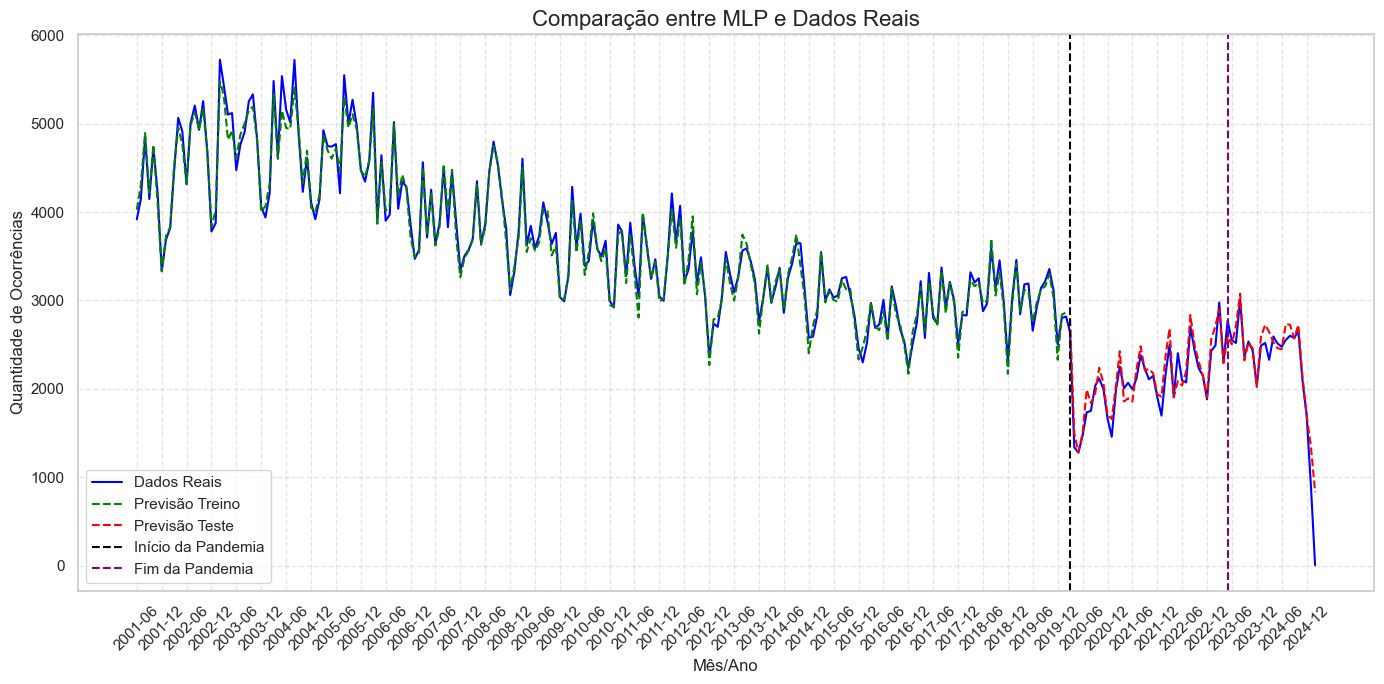

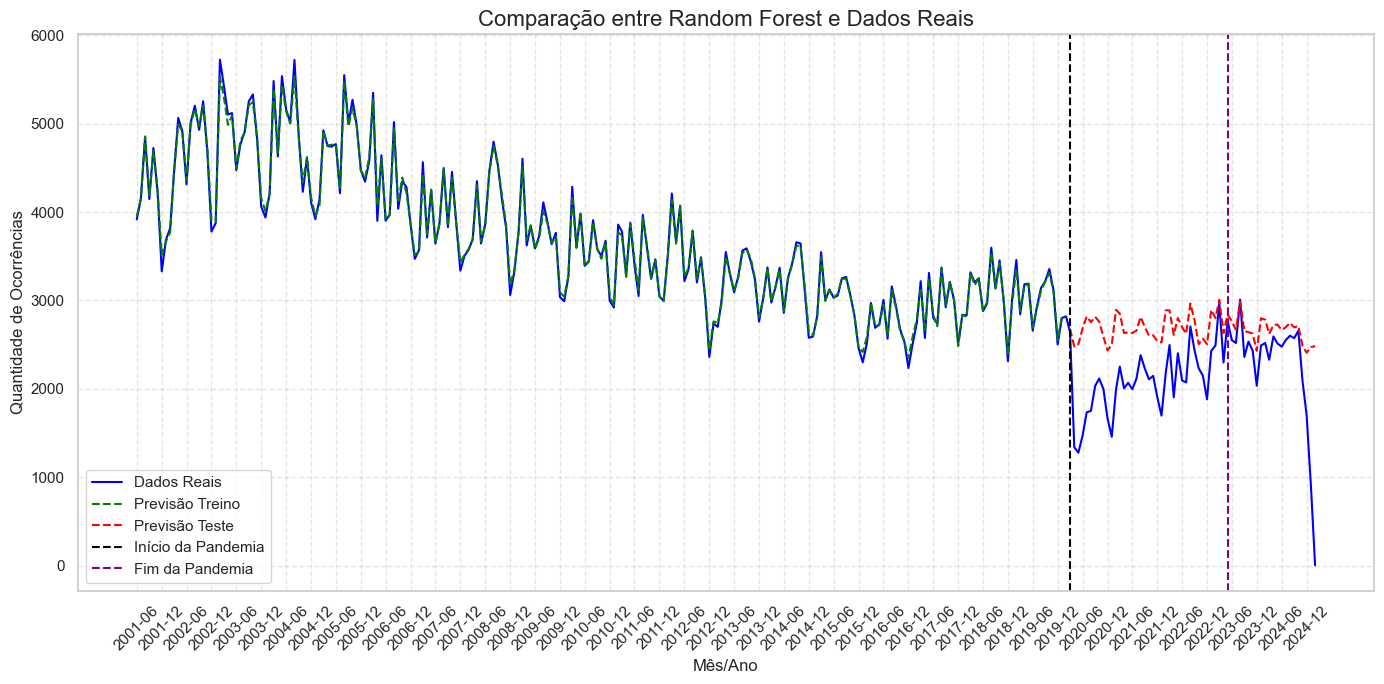

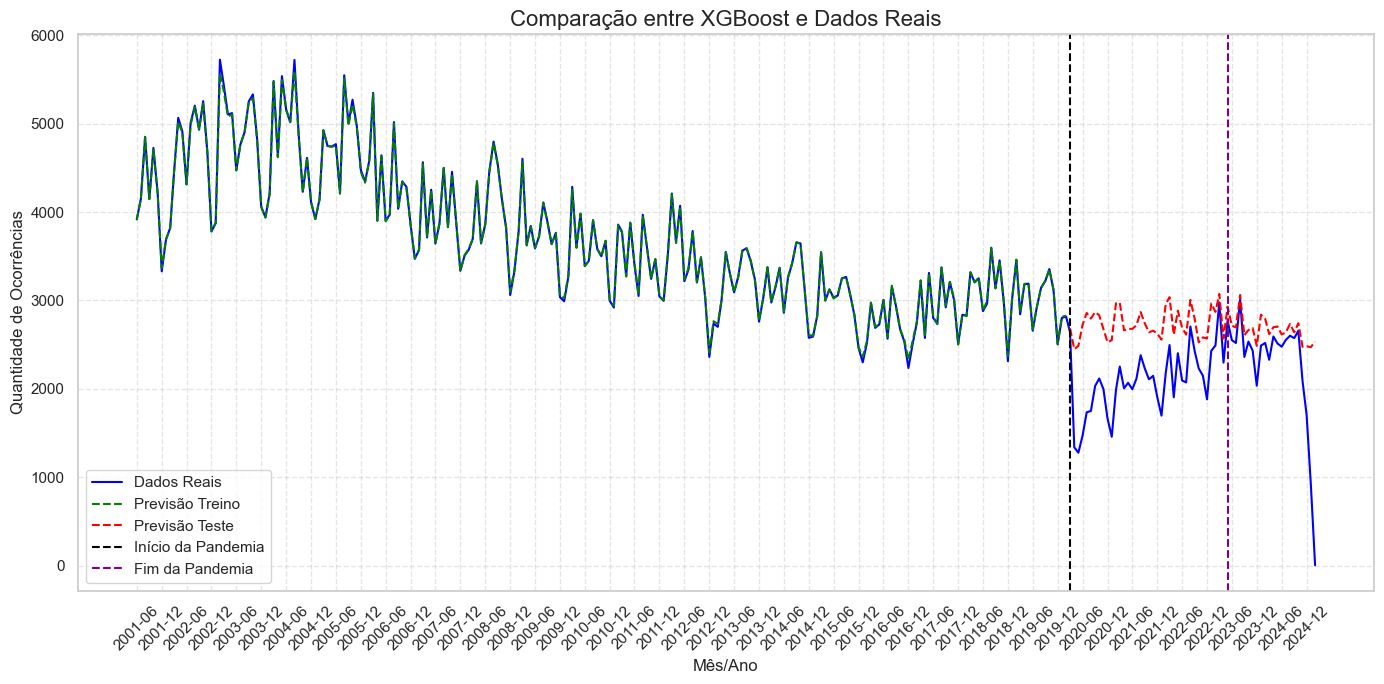

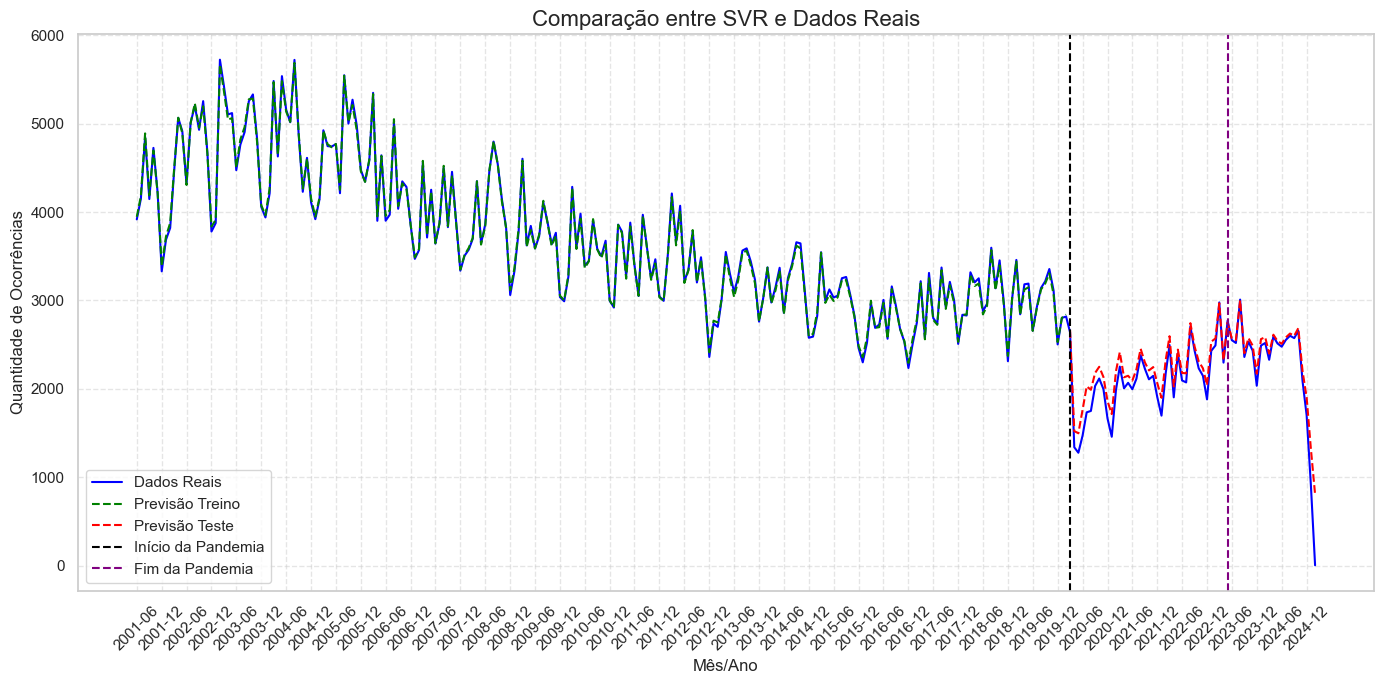

In [178]:
# Comparação dos erros
modelos_treino = {
    "MLP": y_pred_nn_treino,
    "Random Forest": y_pred_rf_treino,
    "XGBoost": y_pred_xgb_treino,
    "SVR": y_pred_svr_treino
}

modelos_teste = {
    "MLP": y_pred_nn_teste,
    "Random Forest": y_pred_rf_teste,
    "XGBoost": y_pred_xgb_teste,
    "SVR": y_pred_svr_teste
}

# Calcular MSE para cada modelo
print("Erro Quadrático Médio (MSE):")
for nome_modelo in modelos_treino.keys():
    # Concatenar previsões de treino e teste
    y_pred_treino = modelos_treino[nome_modelo]
    y_pred_teste = modelos_teste[nome_modelo]
    
    # Calcular MSE separado para treino e teste
    mse_treino = mean_squared_error(dados_agrupados["quantidade"][mask_treino], y_pred_treino)
    mse_teste = mean_squared_error(dados_agrupados["quantidade"][mask_teste], y_pred_teste)
    
    print(f"{nome_modelo} - Treino: {mse_treino:.4f}, Teste: {mse_teste:.4f}")

# Plotar os resultados
for nome_modelo in modelos_treino.keys():
    plt.figure(figsize=(14, 7))
    plt.plot(dados_agrupados["ANO_MES"], dados_agrupados["quantidade"], label="Dados Reais", color="blue")
    plt.plot(dados_agrupados["ANO_MES"][mask_treino], modelos_treino[nome_modelo], label="Previsão Treino", color="green", linestyle="--")
    plt.plot(dados_agrupados["ANO_MES"][mask_teste], modelos_teste[nome_modelo], label="Previsão Teste", color="red", linestyle="--")
    
    # Adicionar linhas verticais para início e fim da pandemia
    plt.axvline(pd.to_datetime("2020-03"), color="black", linestyle="--", label="Início da Pandemia")
    fim_pandemia = pd.to_datetime("2023-05").toordinal()
    plt.axvline(pd.to_datetime("2023-05"), color="purple", linestyle="--", label="Fim da Pandemia")
    
    plt.title(f"Comparação entre {nome_modelo} e Dados Reais", fontsize=16)
    plt.xlabel("Mês/Ano")
    plt.ylabel("Quantidade de Ocorrências")
    xticks = pd.date_range(dados_agrupados["ANO_MES"].min(), dados_agrupados["ANO_MES"].max(), freq="6MS")
    plt.xticks(xticks, labels=[tick.strftime('%Y-%m') for tick in xticks], rotation=45)
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


### Preparação para previsões em todo o período

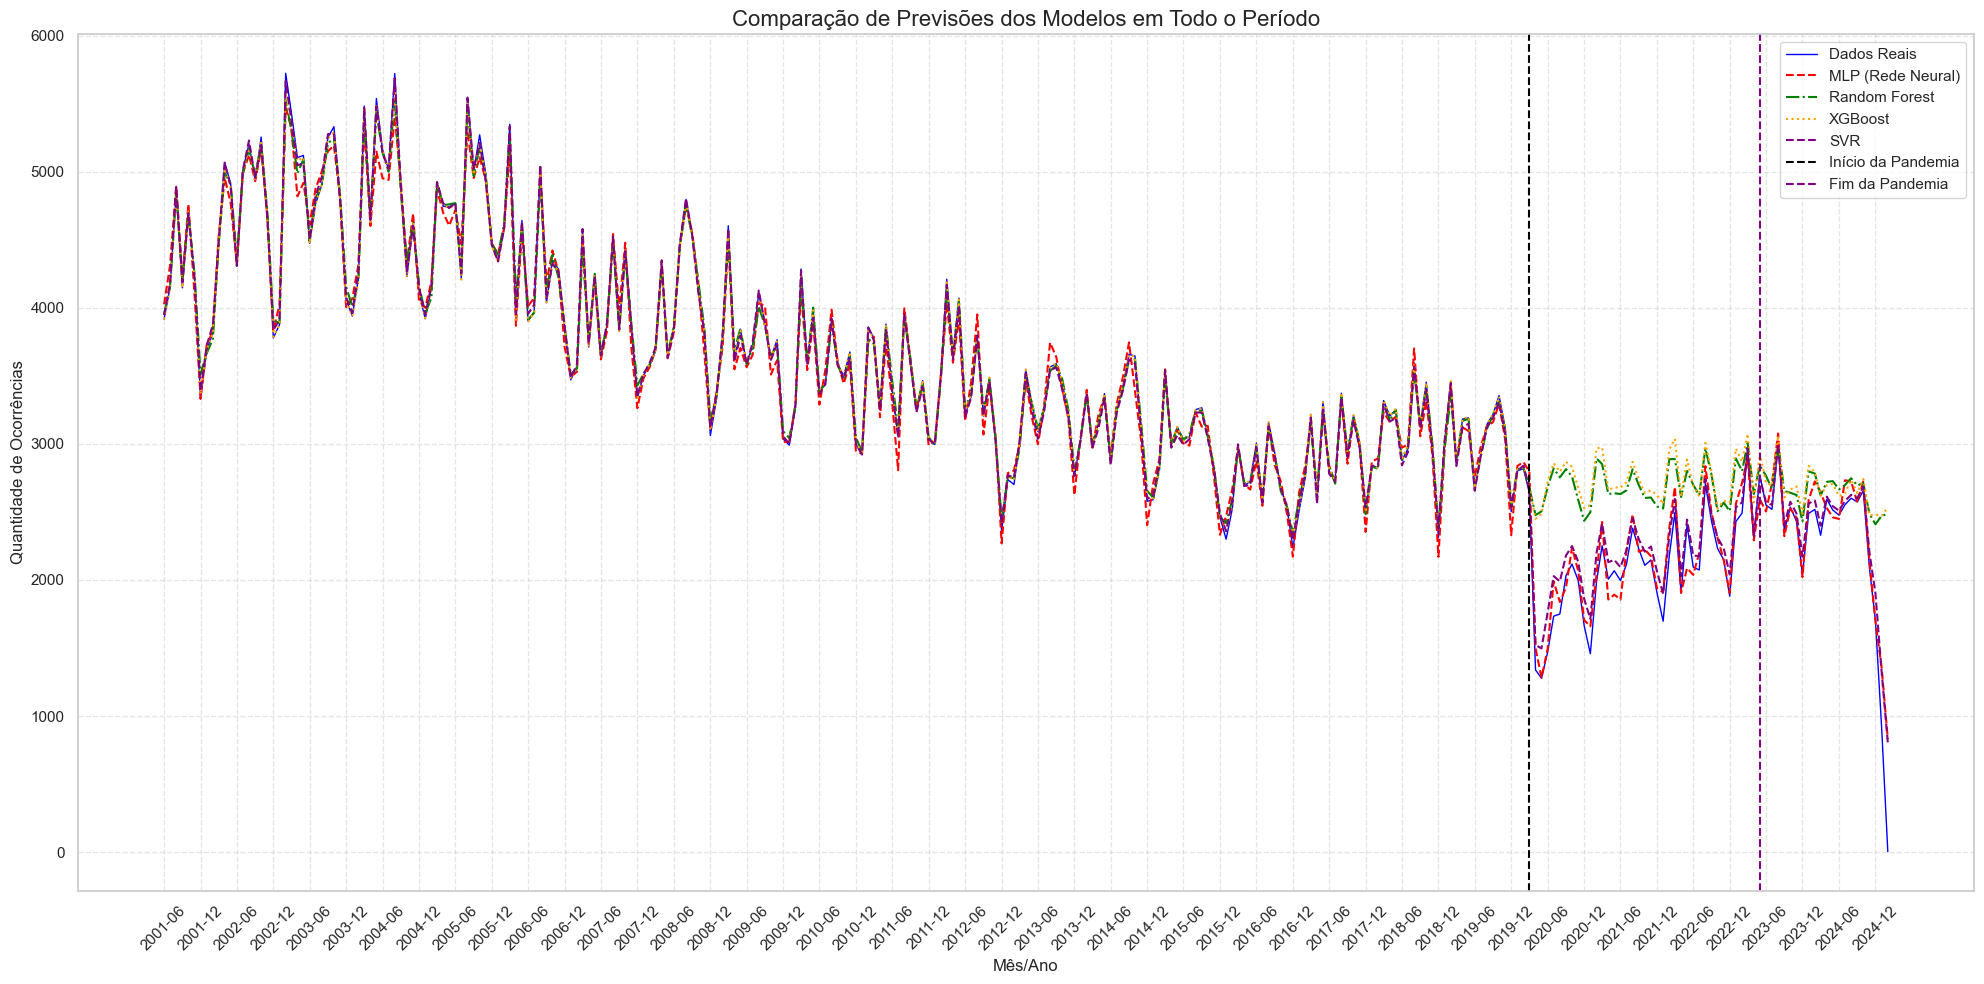

Erro Quadrático Médio (MSE) em Todo o Período:
MLP: 14350.7930
Random Forest: 97875.9907
XGBoost: 105101.7969
SVR: 6812.4666


In [179]:
# Preparação para previsões em todo o período
X_total = X_scaled  # Usar todos os dados
y_real_total = y  # Dados reais (não escalonados)

# Previsões em todo o período
with torch.no_grad():
    y_pred_nn_total_scaled = modelo_nn(torch.tensor(X_total, dtype=torch.float32).to(device)).cpu().numpy()
y_pred_nn_total = inverter_escalonamento(y_pred_nn_total_scaled)

y_pred_rf_total = inverter_escalonamento(modelo_rf.predict(X_total))
y_pred_xgb_total = inverter_escalonamento(modelo_xgb.predict(X_total))
y_pred_svr_total = inverter_escalonamento(modelo_svr.predict(X_total))

# Plotar os resultados (todo o período)
plt.figure(figsize=(20, 10))

# Dados reais
plt.plot(dados_agrupados["ANO_MES"], y_real_total, label="Dados Reais", color="blue", linewidth=1)

# Previsões
plt.plot(dados_agrupados["ANO_MES"], y_pred_nn_total, label="MLP (Rede Neural)", color="red", linestyle="--")
plt.plot(dados_agrupados["ANO_MES"], y_pred_rf_total, label="Random Forest", color="green", linestyle="-.")
plt.plot(dados_agrupados["ANO_MES"], y_pred_xgb_total, label="XGBoost", color="orange", linestyle=":")
plt.plot(dados_agrupados["ANO_MES"], y_pred_svr_total, label="SVR", color="purple", linestyle="--")

# Adicionar linhas verticais para início e fim da pandemia
plt.axvline(pd.to_datetime("2020-03"), color="black", linestyle="--", label="Início da Pandemia")
fim_pandemia = pd.to_datetime("2023-05").toordinal()
plt.axvline(pd.to_datetime("2023-05"), color="purple", linestyle="--", label="Fim da Pandemia")

# Adicionar informações ao gráfico
plt.title("Comparação de Previsões dos Modelos em Todo o Período", fontsize=16)
plt.xlabel("Mês/Ano")
plt.ylabel("Quantidade de Ocorrências")
xticks = pd.date_range(dados_agrupados["ANO_MES"].min(), dados_agrupados["ANO_MES"].max(), freq="6MS")
plt.xticks(xticks, labels=[tick.strftime('%Y-%m') for tick in xticks], rotation=45)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Comparar os erros para todo o período
mse_nn_total = mean_squared_error(y_real_total, y_pred_nn_total)
mse_rf_total = mean_squared_error(y_real_total, y_pred_rf_total)
mse_xgb_total = mean_squared_error(y_real_total, y_pred_xgb_total)
mse_svr_total = mean_squared_error(y_real_total, y_pred_svr_total)

print(f"Erro Quadrático Médio (MSE) em Todo o Período:")
print(f"MLP: {mse_nn_total:.4f}")
print(f"Random Forest: {mse_rf_total:.4f}")
print(f"XGBoost: {mse_xgb_total:.4f}")
print(f"SVR: {mse_svr_total:.4f}")


#### Função para plotar gráfico individual

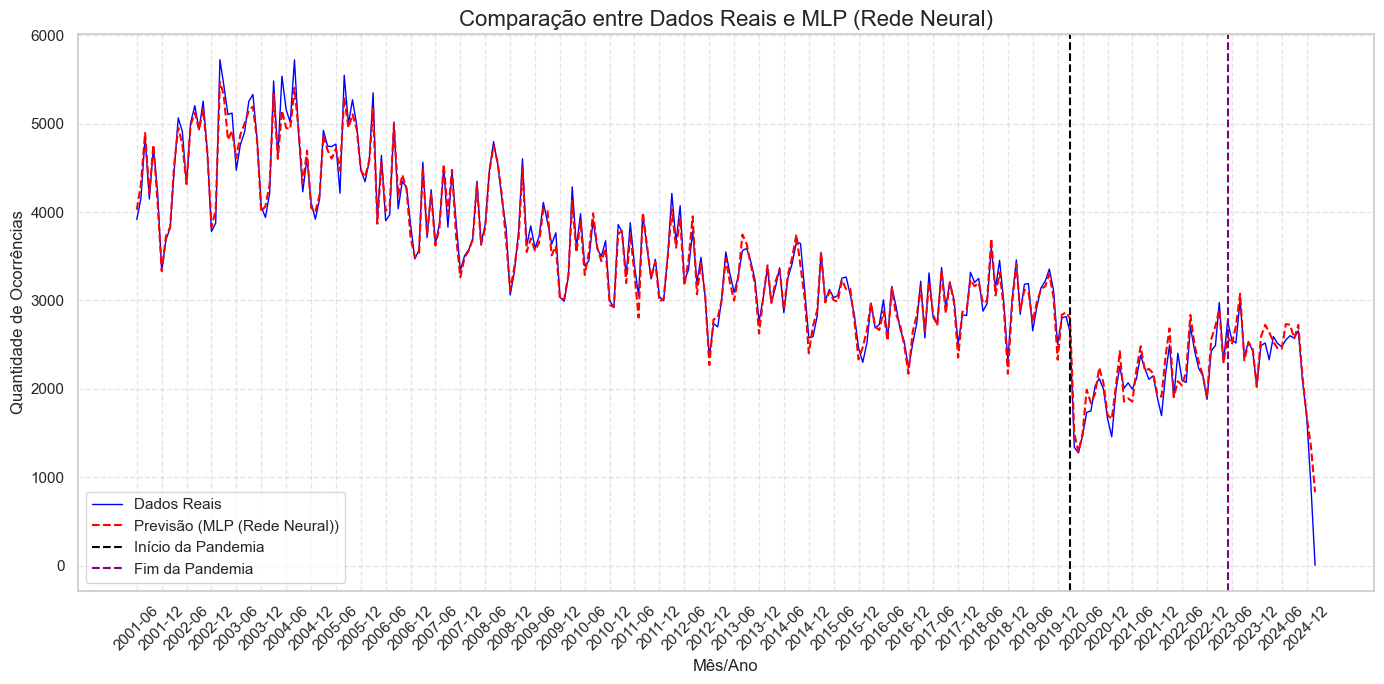

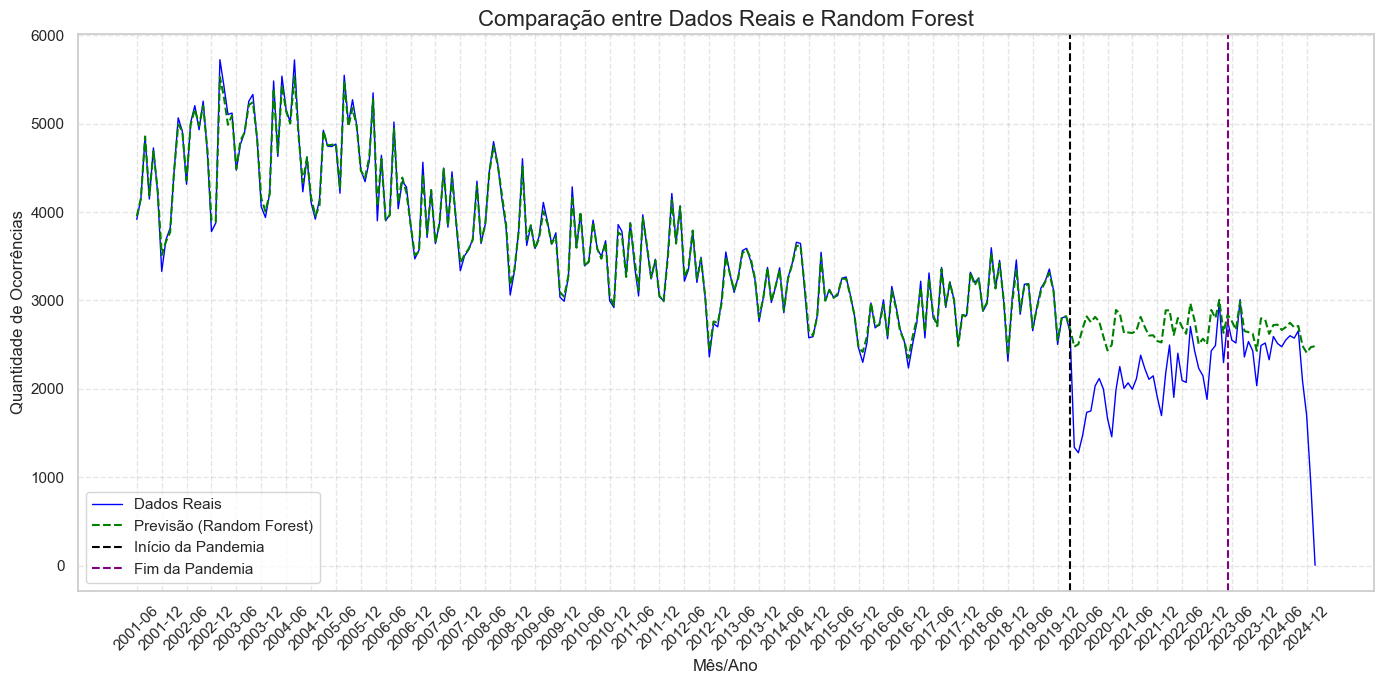

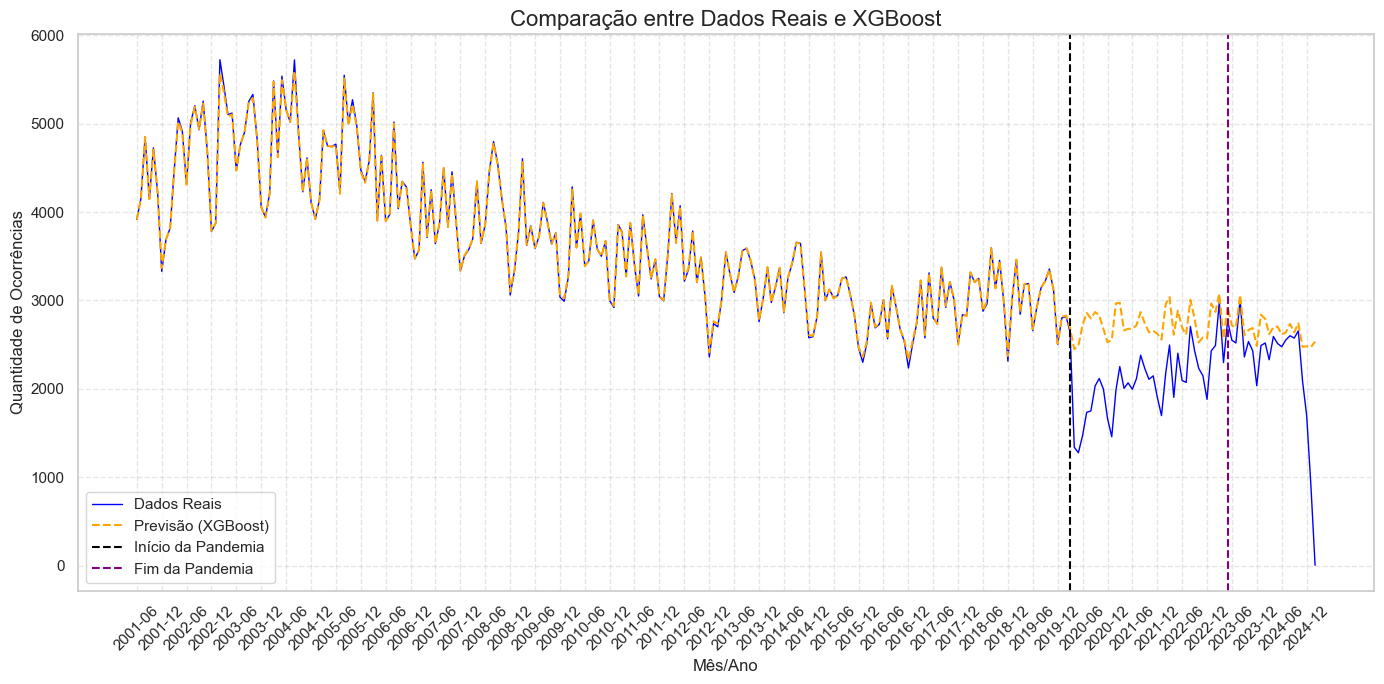

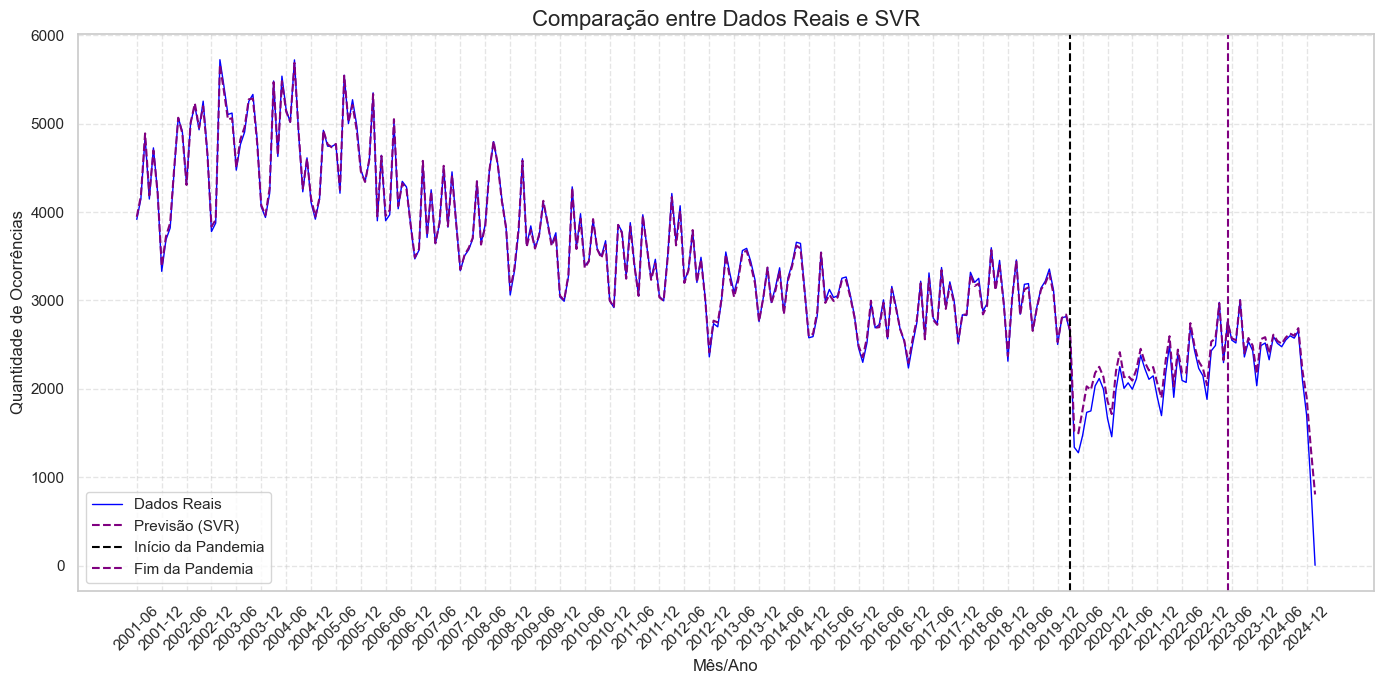

In [180]:
# Função para plotar gráfico individual
def plot_comparacao_modelo(dados_reais, previsoes, modelo_nome, cor_previsao):
    plt.figure(figsize=(14, 7))
    plt.plot(dados_agrupados["ANO_MES"], dados_reais, label="Dados Reais", color="blue", linewidth=1)
    plt.plot(dados_agrupados["ANO_MES"], previsoes, label=f"Previsão ({modelo_nome})", color=cor_previsao, linestyle="--")
    # Adicionar linhas verticais para início e fim da pandemia
    plt.axvline(pd.to_datetime("2020-03"), color="black", linestyle="--", label="Início da Pandemia")
    fim_pandemia = pd.to_datetime("2023-05").toordinal()
    plt.axvline(pd.to_datetime("2023-05"), color="purple", linestyle="--", label="Fim da Pandemia")
    plt.title(f"Comparação entre Dados Reais e {modelo_nome}", fontsize=16)
    plt.xlabel("Mês/Ano")
    plt.ylabel("Quantidade de Ocorrências")
    xticks = pd.date_range(dados_agrupados["ANO_MES"].min(), dados_agrupados["ANO_MES"].max(), freq="6MS")
    plt.xticks(xticks, labels=[tick.strftime('%Y-%m') for tick in xticks], rotation=45)
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

# Plotar os gráficos individuais para cada modelo
plot_comparacao_modelo(y_real_total, y_pred_nn_total, "MLP (Rede Neural)", "red")
plot_comparacao_modelo(y_real_total, y_pred_rf_total, "Random Forest", "green")
plot_comparacao_modelo(y_real_total, y_pred_xgb_total, "XGBoost", "orange")
plot_comparacao_modelo(y_real_total, y_pred_svr_total, "SVR", "purple")


### ModeloNN

Epoch 0: Loss = 0.32359299063682556
Epoch 100: Loss = 0.021723812445998192
Epoch 200: Loss = 0.011795083992183208
Epoch 300: Loss = 0.008276738226413727
Epoch 400: Loss = 0.007140780333429575
Epoch 500: Loss = 0.005481726489961147
Epoch 600: Loss = 0.005991565063595772
Epoch 700: Loss = 0.004794669337570667
Epoch 800: Loss = 0.003434566082432866
Early stopping na época 844
MSE no conjunto de treino: 18706.130859375
MSE no conjunto de teste: 279492.375


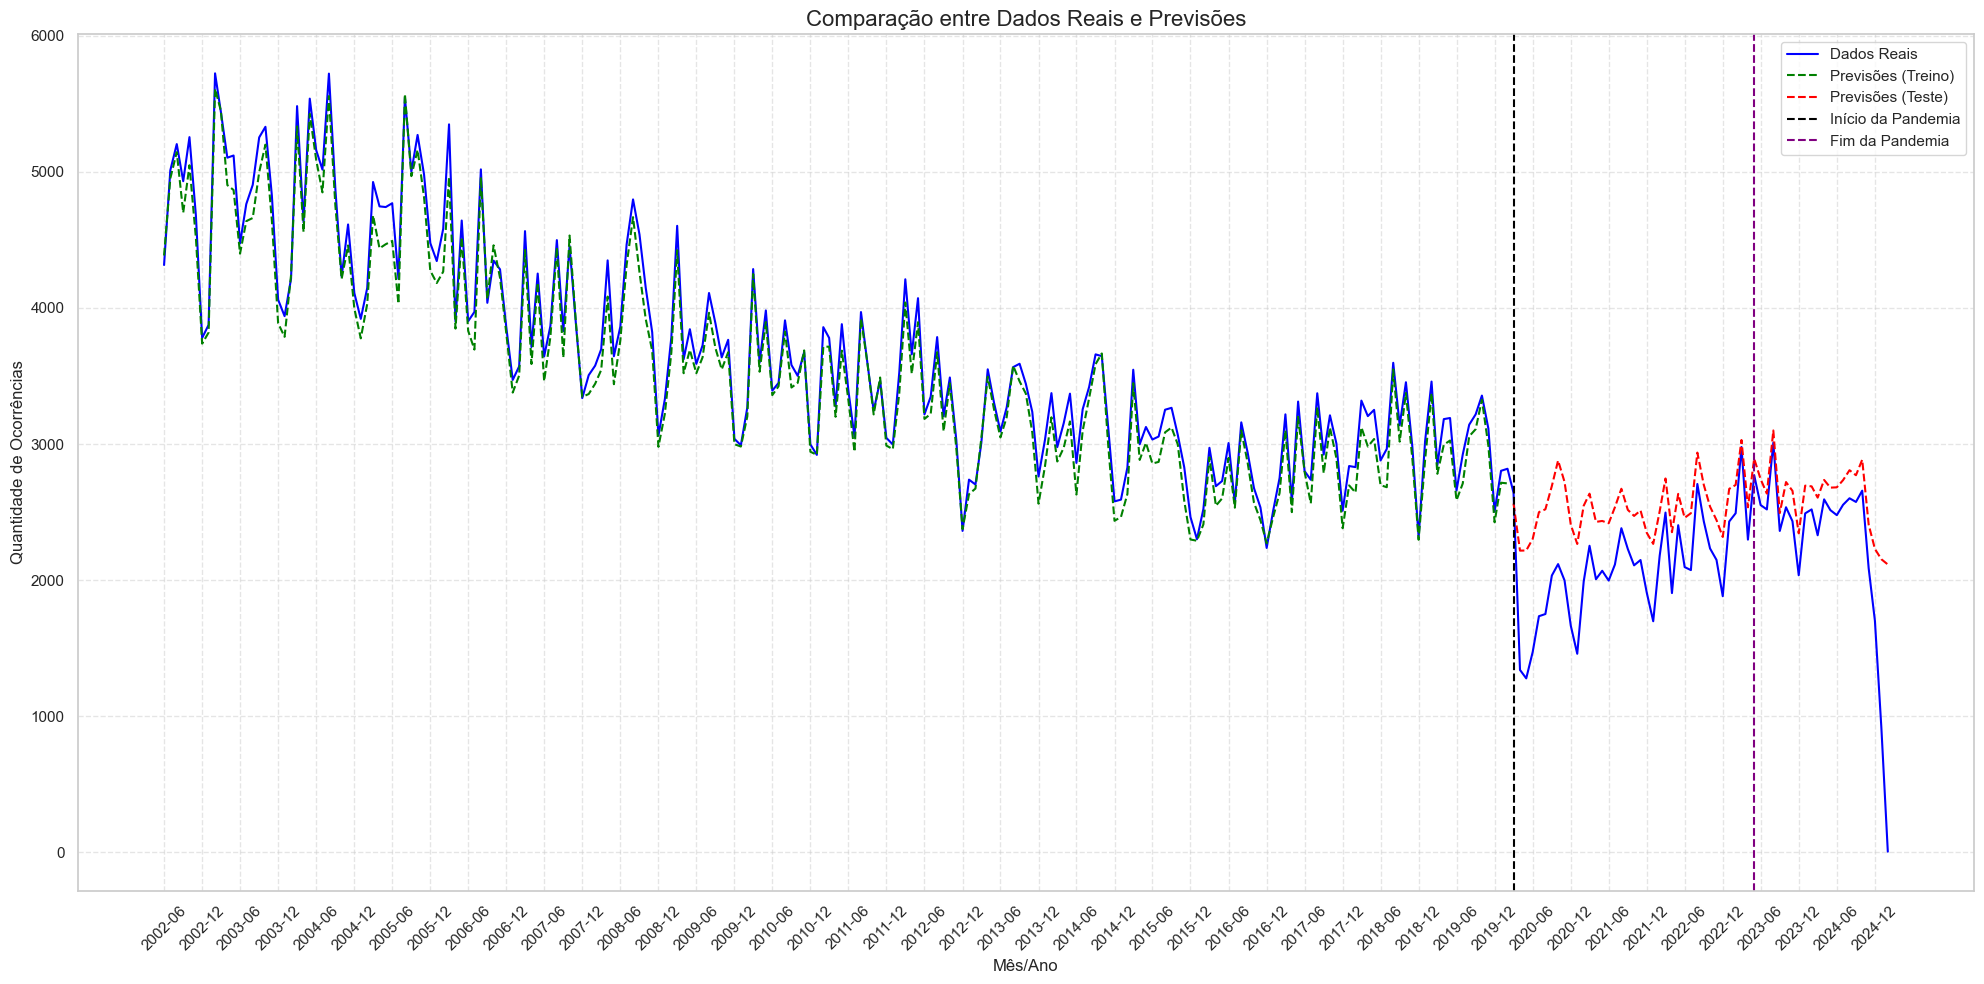

In [181]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error

# Preparação dos Dados
dados_agrupados["ANO_MES"] = pd.to_datetime(dados_agrupados["ANO_MES"], format='%Y-%m')
dados_agrupados["ANO_MES_NUM"] = dados_agrupados["ANO_MES"].map(lambda x: x.toordinal())

# Engenharia de recursos mais robusta
dados_agrupados["LAG_1"] = dados_agrupados["quantidade"].shift(1)
dados_agrupados["LAG_2"] = dados_agrupados["quantidade"].shift(2)
dados_agrupados["LAG_3"] = dados_agrupados["quantidade"].shift(3)
dados_agrupados["LAG_6"] = dados_agrupados["quantidade"].shift(6)
dados_agrupados["LAG_12"] = dados_agrupados["quantidade"].shift(12)
dados_agrupados["MEDIA_MOVEL_3"] = dados_agrupados["quantidade"].rolling(window=3).mean()
dados_agrupados["MEDIA_MOVEL_6"] = dados_agrupados["quantidade"].rolling(window=6).mean()
dados_agrupados["DIFF"] = dados_agrupados["quantidade"].diff()
dados_agrupados["DIFF_2"] = dados_agrupados["quantidade"].diff(2)
dados_agrupados["MES"] = dados_agrupados["ANO_MES"].dt.month
dados_agrupados["TRIMESTRE"] = dados_agrupados["ANO_MES"].dt.quarter
dados_agrupados["ANO"] = dados_agrupados["ANO_MES"].dt.year
dados_agrupados["TENDENCIA"] = np.arange(len(dados_agrupados))

# Remover valores NaN gerados pelos lags e outros cálculos
dados_agrupados.dropna(inplace=True)

# Separar dados de treino e teste
limite_pandemia = pd.to_datetime("2020-03").toordinal()
mask_treino = dados_agrupados["ANO_MES_NUM"] < limite_pandemia
mask_teste = dados_agrupados["ANO_MES_NUM"] >= limite_pandemia

dados_treino = dados_agrupados[mask_treino]
dados_teste = dados_agrupados[mask_teste]

# Usar mais features para capturar padrões complexos
X_treino = dados_treino[["ANO_MES_NUM", "LAG_1", "LAG_2", "LAG_3", "LAG_6", "LAG_12", 
                         "MEDIA_MOVEL_3", "MEDIA_MOVEL_6", "DIFF", "DIFF_2", "MES", 
                         "TRIMESTRE", "ANO", "TENDENCIA"]].values
y_treino = dados_treino["quantidade"].values.reshape(-1, 1)

X_teste = dados_teste[["ANO_MES_NUM", "LAG_1", "LAG_2", "LAG_3", "LAG_6", "LAG_12", 
                       "MEDIA_MOVEL_3", "MEDIA_MOVEL_6", "DIFF", "DIFF_2", "MES", 
                       "TRIMESTRE", "ANO", "TENDENCIA"]].values
y_teste = dados_teste["quantidade"].values.reshape(-1, 1)

# Escalonamento dos dados - usando StandardScaler para melhor generalização
scaler_X = StandardScaler()
scaler_y = MinMaxScaler()

X_treino_scaled = scaler_X.fit_transform(X_treino)
y_treino_scaled = scaler_y.fit_transform(y_treino)

X_teste_scaled = scaler_X.transform(X_teste)
y_teste_scaled = scaler_y.transform(y_teste)

# Modelo de Rede Neural mais complexo
class ModeloNN(nn.Module):
    def __init__(self, input_size):
        super(ModeloNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 256)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, 128)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 1)
        
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = torch.relu(self.fc3(x))
        x = self.fc4(x)
        return x

# Instanciar o modelo com o número correto de features
input_size = X_treino_scaled.shape[1]
modelo = ModeloNN(input_size)
criterio = nn.MSELoss()
otimizador = optim.Adam(modelo.parameters(), lr=0.0001, weight_decay=1e-5)

# Treinamento com early stopping
modelo.train()
melhor_perda = float('inf')
paciencia = 100
contador = 0
historico_perda = []

for epoch in range(5000):  # Aumentar número de épocas
    inputs = torch.tensor(X_treino_scaled, dtype=torch.float32)
    outputs = torch.tensor(y_treino_scaled, dtype=torch.float32)
    
    otimizador.zero_grad()
    previsoes = modelo(inputs).squeeze()
    perda = criterio(previsoes, outputs.squeeze())
    perda.backward()
    otimizador.step()
    
    historico_perda.append(perda.item())
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss = {perda.item()}")
    
    # Early stopping
    if perda.item() < melhor_perda:
        melhor_perda = perda.item()
        contador = 0
        # Salvar o melhor modelo
        torch.save(modelo.state_dict(), 'melhor_modelo.pth')
    else:
        contador += 1
        if contador >= paciencia:
            print(f"Early stopping na época {epoch}")
            break

# Carregar o melhor modelo
modelo.load_state_dict(torch.load('melhor_modelo.pth'))

# Avaliação
modelo.eval()
with torch.no_grad():
    y_pred_treino_scaled = modelo(torch.tensor(X_treino_scaled, dtype=torch.float32))
    y_pred_teste_scaled = modelo(torch.tensor(X_teste_scaled, dtype=torch.float32))

y_pred_treino = scaler_y.inverse_transform(y_pred_treino_scaled.numpy())
y_pred_teste = scaler_y.inverse_transform(y_pred_teste_scaled.numpy())

# Calcular métricas
mse_treino = mean_squared_error(y_treino, y_pred_treino)
mse_teste = mean_squared_error(y_teste, y_pred_teste)
print(f"MSE no conjunto de treino: {mse_treino}")
print(f"MSE no conjunto de teste: {mse_teste}")

# Plotar resultados
plt.figure(figsize=(20, 10))
plt.plot(dados_agrupados["ANO_MES"], dados_agrupados["quantidade"], label="Dados Reais", color='blue')
plt.plot(dados_treino["ANO_MES"], y_pred_treino, label="Previsões (Treino)", color='green', linestyle='--')
plt.plot(dados_teste["ANO_MES"], y_pred_teste, label="Previsões (Teste)", color='red', linestyle='--')

# Adicionar linhas verticais para início e fim da pandemia
plt.axvline(pd.to_datetime("2020-03"), color="black", linestyle="--", label="Início da Pandemia")
fim_pandemia = pd.to_datetime("2023-05").toordinal()
plt.axvline(pd.to_datetime("2023-05"), color="purple", linestyle="--", label="Fim da Pandemia")

plt.title("Comparação entre Dados Reais e Previsões", fontsize=16)
plt.xlabel("Mês/Ano")
plt.ylabel("Quantidade de Ocorrências")
xticks = pd.date_range(dados_agrupados["ANO_MES"].min(), dados_agrupados["ANO_MES"].max(), freq="6MS")
plt.xticks(xticks, labels=[tick.strftime('%Y-%m') for tick in xticks], rotation=45)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


### Modelo LSTM

Epoch 0: Loss = 1.0005064010620117
Epoch 100: Loss = 0.12799705564975739
Epoch 200: Loss = 0.02084765024483204
Epoch 300: Loss = 0.017561543732881546
Epoch 400: Loss = 0.022116318345069885
Early stopping na época 466


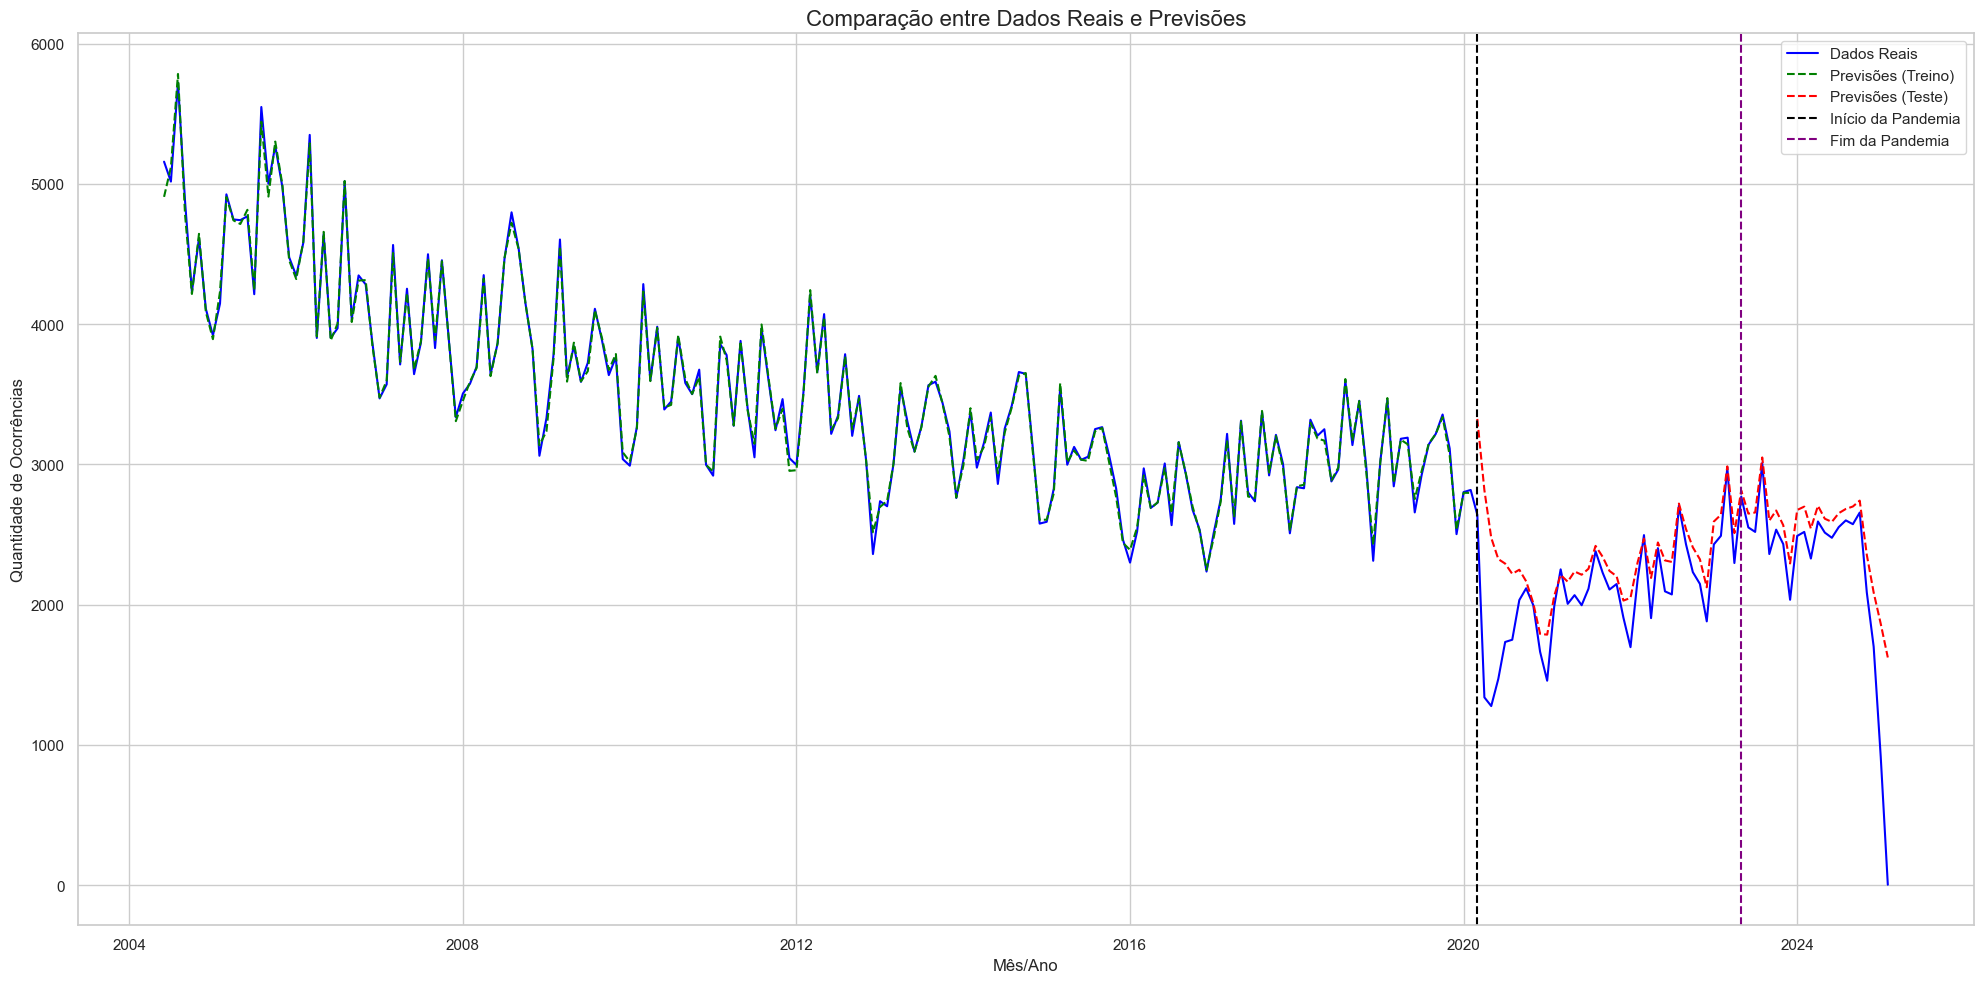

In [182]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error

# Preparação dos Dados
dados_agrupados["ANO_MES"] = pd.to_datetime(dados_agrupados["ANO_MES"], format='%Y-%m')
dados_agrupados["ANO_MES_NUM"] = dados_agrupados["ANO_MES"].map(lambda x: x.toordinal())

# Engenharia de recursos com foco em sazonalidade
dados_agrupados["LAG_1"] = dados_agrupados["quantidade"].shift(1)
dados_agrupados["LAG_2"] = dados_agrupados["quantidade"].shift(2)
dados_agrupados["LAG_3"] = dados_agrupados["quantidade"].shift(3)
dados_agrupados["LAG_6"] = dados_agrupados["quantidade"].shift(6)
dados_agrupados["LAG_12"] = dados_agrupados["quantidade"].shift(12)
dados_agrupados["LAG_24"] = dados_agrupados["quantidade"].shift(24)  # Capturar padrão de 2 anos
dados_agrupados["MEDIA_MOVEL_3"] = dados_agrupados["quantidade"].rolling(window=3).mean()
dados_agrupados["MEDIA_MOVEL_6"] = dados_agrupados["quantidade"].rolling(window=6).mean()
dados_agrupados["MEDIA_MOVEL_12"] = dados_agrupados["quantidade"].rolling(window=12).mean()
dados_agrupados["DIFF"] = dados_agrupados["quantidade"].diff()
dados_agrupados["DIFF_12"] = dados_agrupados["quantidade"].diff(12)  # Diferença anual
dados_agrupados["MES"] = dados_agrupados["ANO_MES"].dt.month
dados_agrupados["SEN_MES"] = np.sin(2 * np.pi * dados_agrupados["MES"]/12)  # Componente sazonal
dados_agrupados["COS_MES"] = np.cos(2 * np.pi * dados_agrupados["MES"]/12)  # Componente sazonal
dados_agrupados["TRIMESTRE"] = dados_agrupados["ANO_MES"].dt.quarter
dados_agrupados["TENDENCIA"] = np.arange(len(dados_agrupados))
dados_agrupados["ANO"] = dados_agrupados["ANO_MES"].dt.year

# Remover valores NaN gerados pelos lags e outros cálculos
dados_agrupados.dropna(inplace=True)

# Separar dados de treino e teste
limite_pandemia = pd.to_datetime("2020-03").toordinal()
mask_treino = dados_agrupados["ANO_MES_NUM"] < limite_pandemia
mask_teste = dados_agrupados["ANO_MES_NUM"] >= limite_pandemia

dados_treino = dados_agrupados[mask_treino]
dados_teste = dados_agrupados[mask_teste]

# Selecionar features
features = ["ANO_MES_NUM", "LAG_1", "LAG_2", "LAG_3", "LAG_6", "LAG_12", "LAG_24",
            "MEDIA_MOVEL_3", "MEDIA_MOVEL_6", "MEDIA_MOVEL_12", "DIFF", "DIFF_12",
            "MES", "SEN_MES", "COS_MES", "TRIMESTRE", "TENDENCIA", "ANO"]

X_treino = dados_treino[features].values
y_treino = dados_treino["quantidade"].values.reshape(-1, 1)

X_teste = dados_teste[features].values
y_teste = dados_teste["quantidade"].values.reshape(-1, 1)

# Usar StandardScaler em vez de MinMaxScaler para lidar melhor com outliers
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_treino_scaled = scaler_X.fit_transform(X_treino)
y_treino_scaled = scaler_y.fit_transform(y_treino)

X_teste_scaled = scaler_X.transform(X_teste)
y_teste_scaled = scaler_y.transform(y_teste)

# Modelo LSTM para capturar dependências temporais
class ModeloLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.3):
        super(ModeloLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc1 = nn.Linear(hidden_size, 64)
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(64, 1)
        
    def forward(self, x):
        # Adicionar dimensão de batch e sequência para LSTM
        x = x.unsqueeze(0)
        out, _ = self.lstm(x)
        out = out.squeeze(0)
        out = torch.relu(self.fc1(out))
        out = self.dropout(out)
        out = self.fc2(out)
        return out

# Instanciar o modelo
input_size = X_treino_scaled.shape[1]
modelo = ModeloLSTM(input_size)
criterio = nn.MSELoss()
otimizador = optim.Adam(modelo.parameters(), lr=0.0005, weight_decay=1e-5)

# Treinamento com learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(otimizador, 'min', patience=20, factor=0.5)
modelo.train()
melhor_perda = float('inf')
paciencia = 100
contador = 0

for epoch in range(5000):
    inputs = torch.tensor(X_treino_scaled, dtype=torch.float32)
    outputs = torch.tensor(y_treino_scaled, dtype=torch.float32)
    
    otimizador.zero_grad()
    previsoes = modelo(inputs).squeeze()
    perda = criterio(previsoes, outputs.squeeze())
    perda.backward()
    otimizador.step()
    
    scheduler.step(perda)
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss = {perda.item()}")
    
    # Early stopping
    if perda.item() < melhor_perda:
        melhor_perda = perda.item()
        contador = 0
        torch.save(modelo.state_dict(), 'melhor_modelo.pth')
    else:
        contador += 1
        if contador >= paciencia:
            print(f"Early stopping na época {epoch}")
            break

# Carregar o melhor modelo
modelo.load_state_dict(torch.load('melhor_modelo.pth'))

# Avaliação
modelo.eval()
with torch.no_grad():
    y_pred_treino_scaled = modelo(torch.tensor(X_treino_scaled, dtype=torch.float32))
    y_pred_teste_scaled = modelo(torch.tensor(X_teste_scaled, dtype=torch.float32))

y_pred_treino = scaler_y.inverse_transform(y_pred_treino_scaled.numpy())
y_pred_teste = scaler_y.inverse_transform(y_pred_teste_scaled.numpy())

# Plotar resultados
plt.figure(figsize=(20, 10))
plt.plot(dados_agrupados["ANO_MES"], dados_agrupados["quantidade"], label="Dados Reais", color='blue')
plt.plot(dados_treino["ANO_MES"], y_pred_treino, label="Previsões (Treino)", color='green', linestyle='--')
plt.plot(dados_teste["ANO_MES"], y_pred_teste, label="Previsões (Teste)", color='red', linestyle='--')
# Adicionar linhas verticais para início e fim da pandemia
plt.axvline(pd.to_datetime("2020-03"), color="black", linestyle="--", label="Início da Pandemia")
fim_pandemia = pd.to_datetime("2023-05").toordinal()
plt.axvline(pd.to_datetime("2023-05"), color="purple", linestyle="--", label="Fim da Pandemia")
plt.title("Comparação entre Dados Reais e Previsões", fontsize=16)
plt.xlabel("Mês/Ano")
plt.ylabel("Quantidade de Ocorrências")
plt.tight_layout()
plt.legend()
plt.grid(True)
plt.show()
